**Realizado por:**

- Guadalupe Castillo Ochoa
- Kevin Santiago Restrepo Alzate
- Luis David Botero Palacio

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', None)         # no corta el ancho de la línea
pd.set_option('display.max_colwidth', None)  # no trunca el contenido de cada celda


In [61]:
RUTA_ARCHIVO = "Estudiantes_cursos_procesado_enriquecido.xlsx"
df = pd.read_excel(RUTA_ARCHIVO)
df.columns = (
    df.columns.str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Integración de los datos

## Asignación de tipo de dato correcto

In [62]:

COLUMNAS_FECHA = [
    "Fecha de Nacmto",
]

for col in COLUMNAS_FECHA:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [63]:
COLUMNAS_ID_NUMERICAS = [
    "ID Estudiante",
    "ID_docente",
]

for col in COLUMNAS_ID_NUMERICAS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

In [64]:
COLUMNAS_NUMERICAS = [
    "# Cancelaciones totales",
    "%Cancelación",
    "Nota Curso",
    "Créditos Aprobados",
    "Créditos Inscritos Totales",
    "Créditos Cancelados",
    "Cursos Cancelados",
    "Edad",
    "Créditos Reprobados Totales",
    "Total Créditos Académicos",
    "Nota Parcial",
    "# Periodos Programa Actual",
    "Créditos Cancelados Progr. Actual",
    "Créditos Reprobados Progr. Actual",
    "Créditos Aprobados Progr. Actual",
    "Promedio Notas Parciales",
    "Créditos Académicos",
    "Promedio notas",
    "Promedio Notas Prog. Actual",
    "creditos_aprobados_hist",
    "creditos_reprobados_hist",
    "cursos_reprobados_hist",
    "cursos_tomados_hist",
    "tasa_aprobacion_hist",
    "promedio_notas_hist",
    "num_periodos_cursados",
    "tasa_aprobacion_materia_hist",
    "tasa_aprobacion_docente_hist",
    "Edad_profesor",
]

for col in COLUMNAS_NUMERICAS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

In [65]:
COLUMNAS_TEXTO_ALTA_CARDINALIDAD = [
    "Ciudad Nacimiento",
    "Nombre Estudiante",
    "Colegio origen",
    "NRC",
    "Docente Principal",
    "Materia-Curso",
    "Título Curso",
]

for col in COLUMNAS_TEXTO_ALTA_CARDINALIDAD:
    if col in df.columns:
        df[col] = df[col].astype("string")

In [66]:
COLUMNAS_CATEGORICAS = [
    "Año Saber11",
    "Período Académico",
    "Semestre",
    "Año semestre",
    "# Cancelaciones",
    "Naturaleza Colegio",
    "Cursos Reprobados",
    "Departamento Colegio",
    "Departamento Nacimiento",
    "Estrato",
    "Género",
    "Método Asistencia Curso",
    "País Nacimiento",
    "Tipo Alumno",
    "# Aprobaciones",
    "Ubicación",
    "Programa1",
    "Aprobado",
    "Escuela",
    "Género_profesor",
    "Nivel Formación",
    "Rol",
    "Tipo Empleado",
    "Vinculación",
    "Categoria_Materia",
    "Zona_Ciudad_Nacimiento",
    "Tipo_Municipio_Nacimiento",
    "Confianza_Zona",
    "Título Curso",
]

for col in COLUMNAS_CATEGORICAS:
    if col in df.columns:
        df[col] = df[col].astype("category")


In [67]:
df.sample(10)

,Año Saber11,Período Académico,Semestre,Año semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Ciudad Nacimiento,ID Estudiante,Nombre Estudiante,Colegio origen,Nota Curso,NRC,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Docente Principal,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Materia-Curso,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,Título Curso,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,ID_docente,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
32542,2023.0,202520,20,2025,0,0.0,0.0,Medellín,551499,ANA SOFIA MARIN MIRANDA,LIC FRANCISCO RTREPO MOLINA MX,3.91,30498,4.0,2007-04-08,4.0,0.0,NO OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,DINA MARIA POSADA ZULETA - 4747,18.0,2,0.0,F,4.0,6069-0065,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,4.0,C - Estudiante matriculado,INVESTIGACIÓN Y PLANEACIÓN EST,1,4.0,4.250000,4.0,3.91,3.91,Gestión del empren y la innova,1,58.0,3.0,1.0,28.0,0.678571,3.907857,3.0,0.965066,4747,0.920000,"Economía, Administración y Negocios",F,50.0,012-Maestria,Académico,DEF - Docente Externo de Facultad,Interno,Formación Profesional Específica,Urbana,Ciudad / aglomeración,Alta
10672,2018.0,202420,20,2024,0,0.0,0.0,Ibagué,393314,VALENTINA ALEXANDRA CARRERA CORREA,LIC MUNICIPAL CONCEJO DE MED,4.40,20925,3.0,2002-01-15,3.0,0.0,OFICIAL,0.0,0,ANTIOQUIA,Tolima-CO,ANA MARIA VELEZ EVANS - 22840,22.0,Sin dato,0.0,F,3.0,3313-0041,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,3.0,C - Estudiante matriculado,INVESTIGACIÓN II,1,6.0,4.290909,3.0,4.40,4.40,Negocios Internal-Med,1,90.0,18.0,6.0,43.0,0.837209,3.529302,9.0,0.932632,22840,0.870130,"Economía, Administración y Negocios",F,47.0,013-Doctorado,Académico,DIF - Docente Interno de Facultad,Interno,Investigación,Urbana,Ciudad / aglomeración,Alta
4957,2021.0,202320,20,2023,0,0.0,0.0,Cartagena,246823,ALEX CAMILO AGUDELO FRANCO,COLEGIO DE LA UNIVERSIDAD PONTIFICIA BOLIVARIANA,2.85,19691,0.0,2003-01-12,3.0,0.0,NO OFICIAL,0.0,1,ANTIOQUIA,Bolívar-CO,DIANA MARCELA HURTADO ZAPATA - 76853,20.0,4,3.0,M,3.0,9937-0055,C - Clase presencial,NaN,Colombia,8.0,0.0,3.0,0.0,C - Estudiante matriculado,CÁLCULO I,0,2.0,3.063636,3.0,2.85,2.85,Negocios Internal-Med,0,44.0,10.0,4.0,20.0,0.500000,3.394500,3.0,0.749654,76853,0.457627,"Economía, Administración y Negocios",F,43.0,012-Maestria,Académico,DEF - Docente Externo de Facultad,Externo,Ciencia Básica,Urbana,Ciudad / aglomeración,Alta
18596,2020.0,202220,20,2022,0,0.0,0.0,Medellín,452991,SEBASTIAN ZULUAGA GAVIRIA,INS ED FE Y ALEGRIA LUIS AMIGO,4.23,52394,3.0,2003-09-08,3.0,0.0,OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,JUAN CAMILO GALVIS CIRO - 334116,19.0,2,0.0,M,3.0,6611-0027,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,3.0,C - Estudiante matriculado,MACROECONOMÍA,1,2.0,3.528571,3.0,4.23,4.23,Economía - Med,1,32.0,0.0,0.0,14.0,0.928571,4.082143,2.0,0.851852,334116,0.823052,"Economía, Administración y Negocios",M,35.0,013-Doctorado,Académico,DEF - Docente Externo de Facultad,Interno,Formación Profesional Específica,Urbana,Ciudad / aglomeración,Alta
11430,2018.0,202220,20,2022,0,0.0,0.0,Jardín,397921,MARIA CLARA ARREDONDO JARAMILLO,LIC DPTAL INT SAN ANTONIO,4.35,99500,1.0,2001-07-01,1.0,0.0,OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,EDGAR DARIO HOLGUIN GAVIRIA - 7505,21.0,Sin dato,0.0,F,1.0,6069-0059,C - Clase presencial,NaN,

## Validación de datos duplicados

In [68]:
datos_iniciales = len(df)
print(f'Cantidad de datos iniciales: {datos_iniciales}')

# Se eliminan las filas exactamente iguales
df.drop_duplicates(
    inplace = True
)

# Se reinician los index para no tener huecos en ellos
df.reset_index(
    drop=True,
    inplace=True
)

datos_sin_duplicados = len(df)
print(f'Cantidad de datos al eliminar duplicados: {datos_sin_duplicados}')
print(f'Cantidad de datos eliminados por duplicados:{datos_iniciales - datos_sin_duplicados}')

Cantidad de datos iniciales: 35639
Cantidad de datos al eliminar duplicados: 35639
Cantidad de datos eliminados por duplicados:0


Se realiza validación de datos duplicados para limpeza de la base, en la cual no contamos con datos duplicados

# Eliminación de variables irrelevantes y redundantes

## Variables irrelevantes

In [69]:
df.sample(1)

,Año Saber11,Período Académico,Semestre,Año semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Ciudad Nacimiento,ID Estudiante,Nombre Estudiante,Colegio origen,Nota Curso,NRC,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Docente Principal,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Materia-Curso,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,Título Curso,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,ID_docente,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
23573,2021.0,202410,10,2024,0,0.0,0.0,Montelíbano,487379,BRAYAN JAVIER MEZA YEPES,FUNDACION ED DE MONTELIBANO,3.62,21181,2.0,1999-03-06,2.0,0.0,NO OFICIAL,0.0,0,CORDOBA,Córdoba-CO,LUIS HORACIO BOTERO MONTOYA - 6534,25.0,4,0.0,M,2.0,3313-0040,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,2.0,C - Estudiante matriculado,INVESTIGACIÓN I,1,4.0,3.65,2.0,3.62,3.62,Admón de Empresas-Med,1,65.0,6.0,2.0,29.0,0.862069,3.390345,4.0,0.903614,6534,0.933518,Derecho y Ciencias Políticas,M,60.0,013-Doctorado,Académico,DEF - Docente Externo de Facultad,Interno,Investigación,Urbana,Intermedio,Media


In [70]:
COLUMNAS_IRRELEVANTES = [
    'Período Académico','Año semestre', 'Ciudad Nacimiento','ID Estudiante', 'Nombre Estudiante','Colegio origen','NRC','Docente Principal',
    'Materia-Curso','ID_docente','Título Curso'
]

# Se eliminan las columnas irrelevantes
df.drop(
    columns = COLUMNAS_IRRELEVANTES,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Nota Curso,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
26163,2021.0,20,0,0.0,0.0,5.0,2.0,2003-10-20,2.0,0.0,NO OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,20.0,4,0.0,M,2.0,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,2.0,C - Estudiante matriculado,1,2.0,5.0,2.0,5.0,5.0,Negocios Internal-Med,1,27.0,0.0,0.0,11.0,1.0,4.428182,2.0,0.737681,1.0,Ingenierías,M,44.0,012-Maestria,Académico,DEF - Docente Externo de Facultad,Externo,Ciencia Básica,Urbana,Ciudad / aglomeración,Alta


Se eliminan aquellas columnas que no aportan información relevante para la predicción, ademas se eliminan variables con alta cardinalidad y con dimencionamiento jerarquico

In [71]:
COLUMNAS_DATA_LAKAGE = [
    '# Cancelaciones', '# Cancelaciones totales', '%Cancelación', 'Créditos Aprobados','Créditos Inscritos Totales', 'Créditos Cancelados',
    'Cursos Cancelados', 'Cursos Reprobados', 'Créditos Reprobados Totales','Total Créditos Académicos','Nota Parcial','Nota Parcial',
    'País Nacimiento', '# Periodos Programa Actual','Créditos Cancelados Progr. Actual','Créditos Reprobados Progr. Actual',
    'Créditos Aprobados Progr. Actual','# Aprobaciones','Promedio Notas Parciales','Promedio notas','Promedio Notas Prog. Actual'
]

# Se eliminan las columnas identificadas como data lakage
df.drop(
    columns = COLUMNAS_DATA_LAKAGE,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,Nota Curso,Fecha de Nacmto,Naturaleza Colegio,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Género,Método Asistencia Curso,Tipo Alumno,Ubicación,Créditos Académicos,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
25088,2021.0,20,3.0,2003-07-04,OFICIAL,VALLE DEL CAUCA,Valle-CO,19.0,Sin dato,M,C - Clase presencial,N - Nuevo,1.0,4.0,Negocios Internal-Med,1,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.509532,1.0,"Economía, Administración y Negocios",F,41.0,013-Doctorado,Académico,DEF - Docente Externo de Facultad,Externo,Ciencia Básica,Urbana,Ciudad / aglomeración,Alta


Se eliminan aquellas columnas que cuyo valor no pude ser conocido si no hasta que ya pasa el hecho que se desea predecir, lo cual produce data lakage para el ejercicio de predicción

## Variables redundantes matemáticamente

In [72]:
VARIABLES_REDUNDANTES = ['Nota Curso','Fecha de Nacmto']

# Se eliminan las columnas identificadas como data lakage
df.drop(
    columns = VARIABLES_REDUNDANTES,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,Naturaleza Colegio,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Género,Método Asistencia Curso,Tipo Alumno,Ubicación,Créditos Académicos,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
20204,2021.0,20,OFICIAL,CESAR,Cesar-CO,21.0,1,F,G - Requisito de Grado,C - Estudiante matriculado,7.0,1.0,Admón de Empresas-Med,1,104.0,0.0,0.0,40.0,1.0,4.354,6.0,0.945565,0.908676,"Economía, Administración y Negocios",F,37.0,010-Esp. Universitaria,Sin Asignar Rol,IAD - Interno Administrativo,Externo,Práctica,Rural,Rural,Media


Se eliminan aquellas variables que tienen relación lineal con otras dentro del dataframe ya que una de ellas puede ser calculada a partir de la otra

# Descripción estadística de datos

## Variables numéricas

In [73]:
# Estadistica descriptiva
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,35639.0,21.085580,3.085801,16.0,19.000000,21.000000,22.000000,56.0
Créditos Académicos,35639.0,2.651926,1.309023,0.0,2.000000,3.000000,3.000000,10.0
creditos_aprobados_hist,35639.0,67.224726,39.381172,0.0,33.000000,66.000000,99.000000,213.0
creditos_reprobados_hist,35639.0,4.493308,6.847964,0.0,0.000000,2.000000,7.000000,69.0
cursos_reprobados_hist,35639.0,1.646342,2.514889,0.0,0.000000,1.000000,2.000000,26.0
cursos_tomados_hist,35639.0,31.129633,16.957549,1.0,16.000000,30.000000,44.000000,106.0
tasa_aprobacion_hist,35639.0,0.776985,0.208065,0.0,0.666667,0.833333,0.944444,1.0
promedio_notas_hist,35639.0,3.533853,0.738104,0.0,3.143208,3.644545,4.080000,5.0
num_periodos_cursados,35639.0,4.253963,3.267042,0.0,2.000000,4.000000,6.000000,21.0
tasa_aprobacion_materia_hist,35639.0,0.844346,0.124336,0.0,0.787572,0.876339,0.935484,1.0


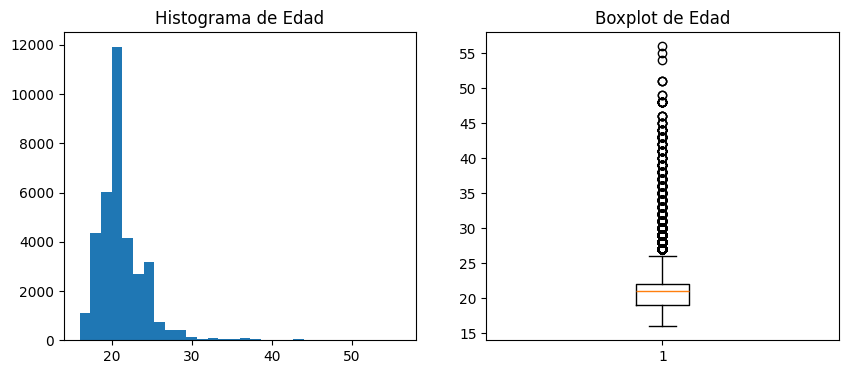

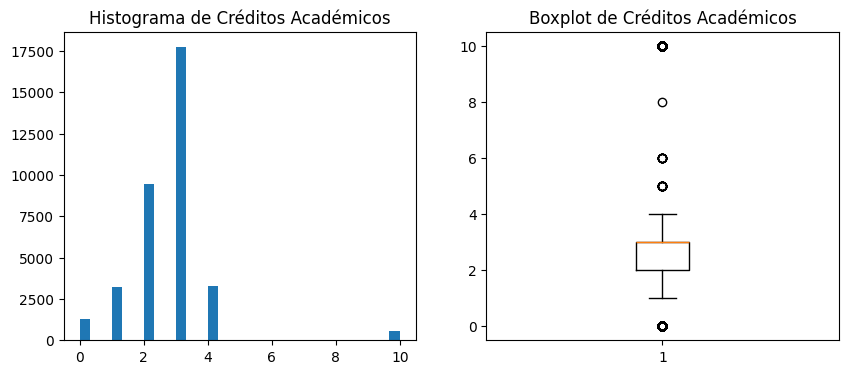

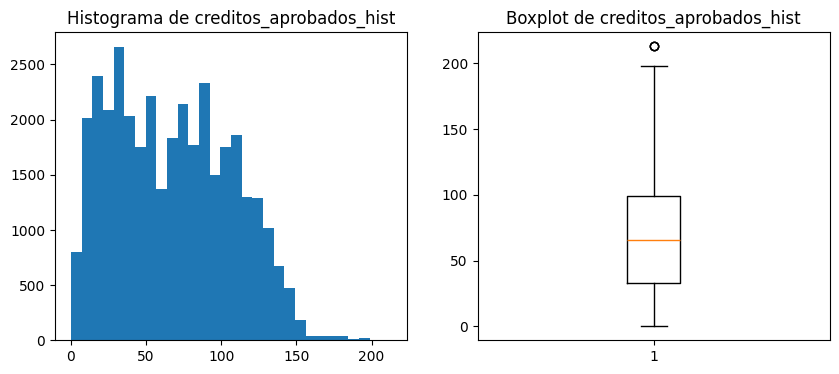

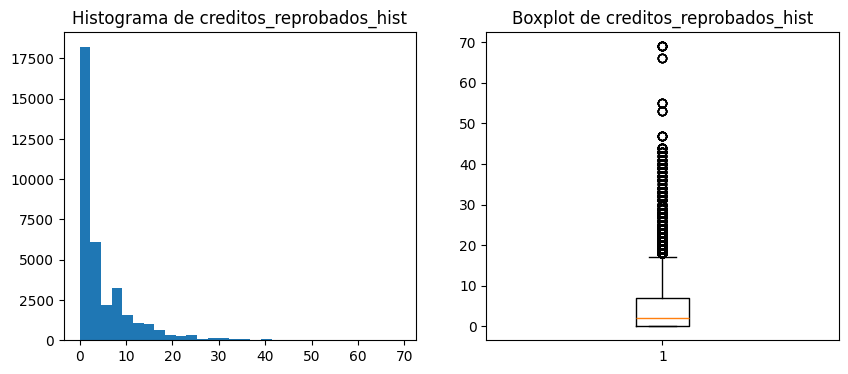

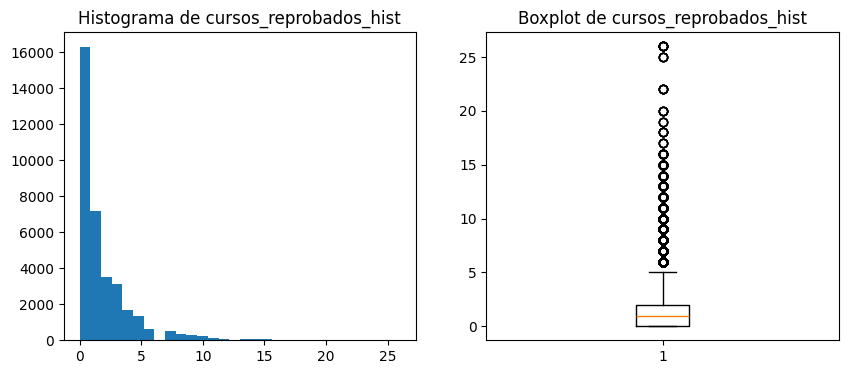

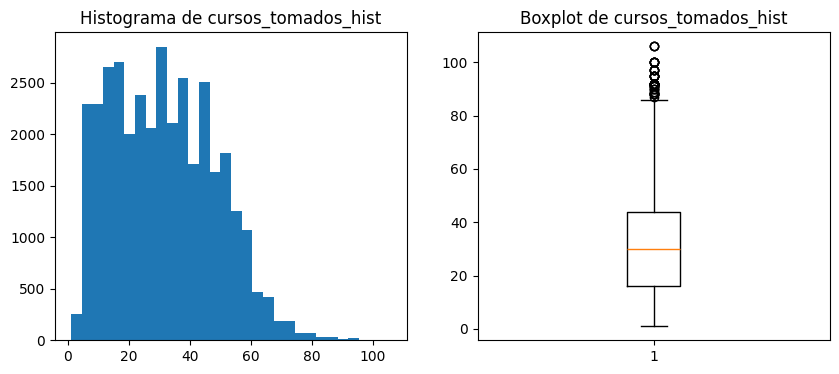

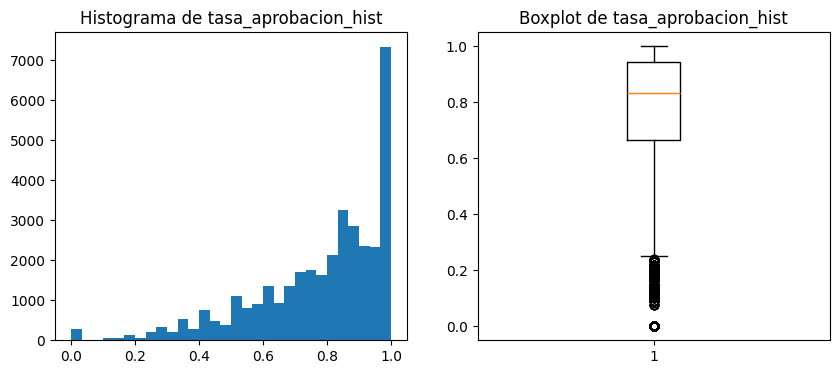

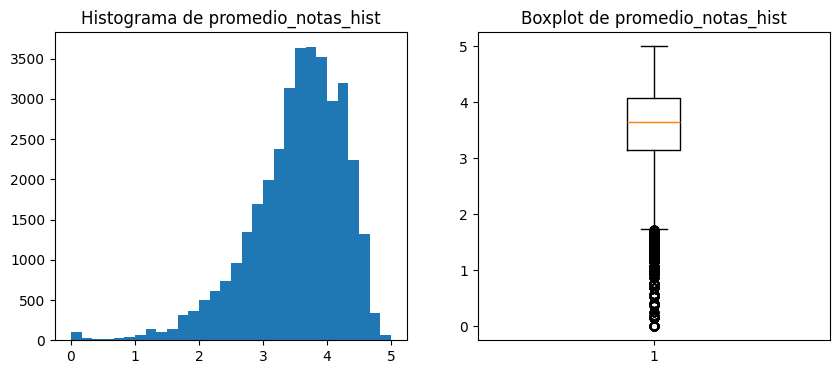

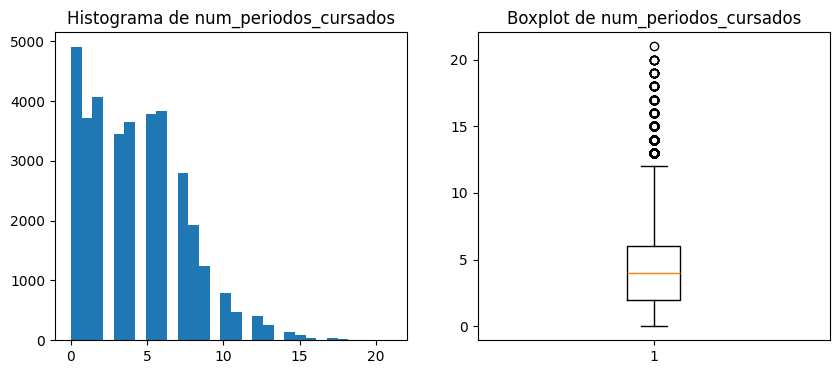

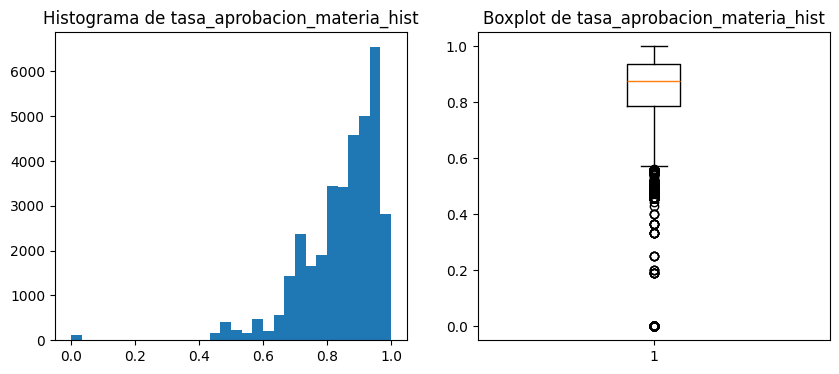

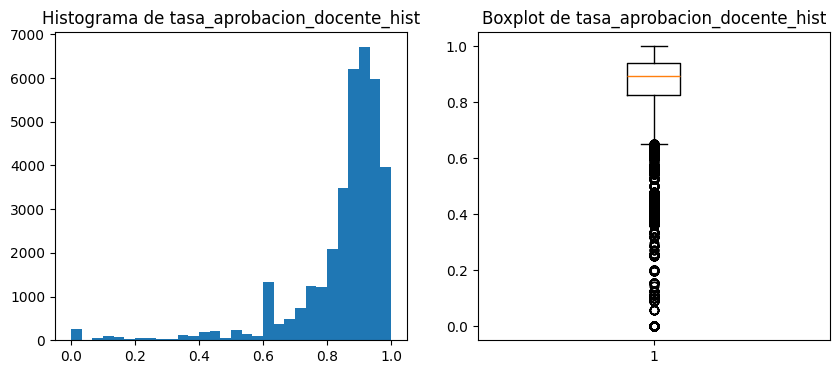

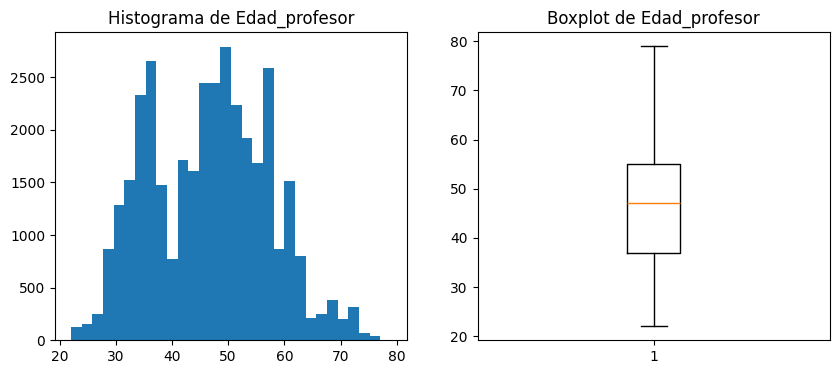

In [74]:
columnas_numericas = df.select_dtypes(include=["float64", "int64", "Int64"]).columns

for col in columnas_numericas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.hist(df[col].dropna(), bins=30)
    ax1.set_title(f"Histograma de {col}")

    ax2.boxplot(df[col].dropna())
    ax2.set_title(f"Boxplot de {col}")

    plt.show()

## Variables categóricas

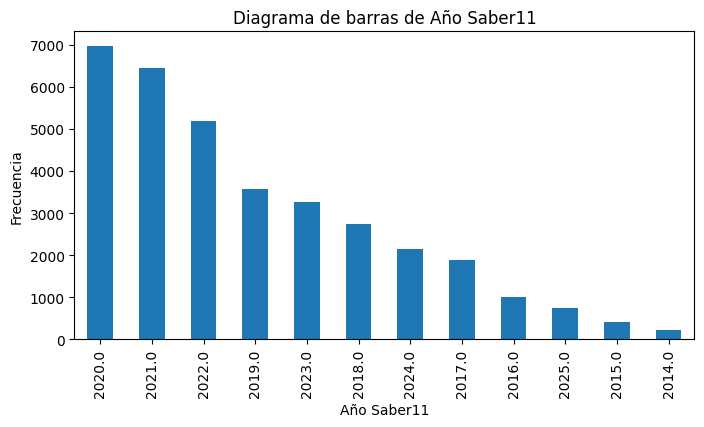

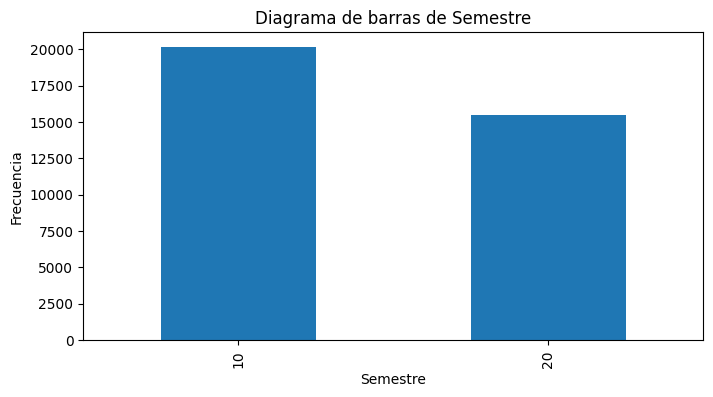

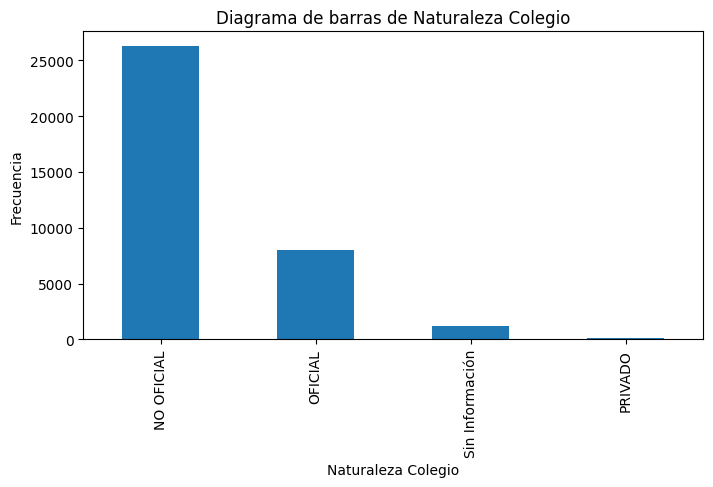

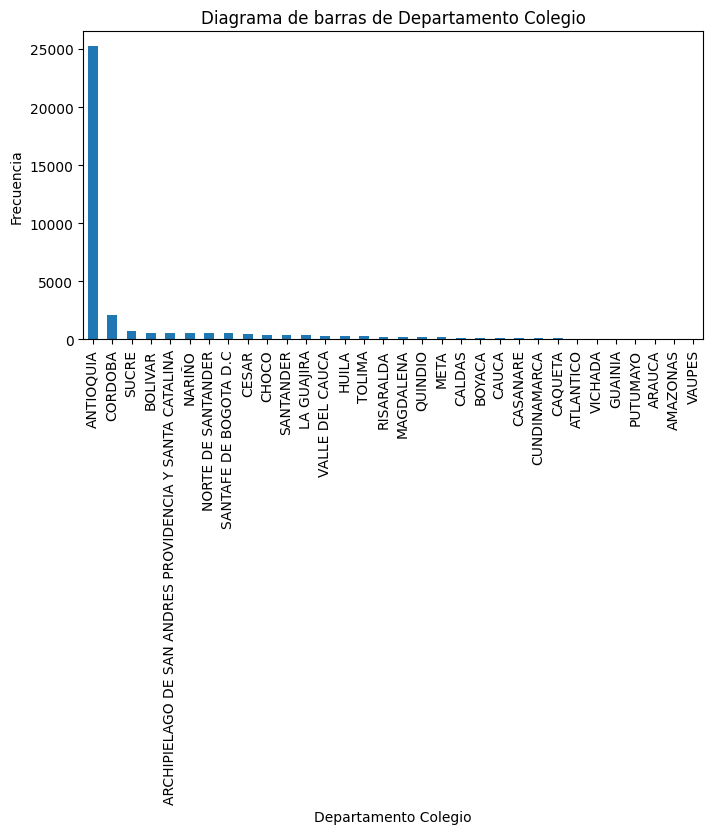

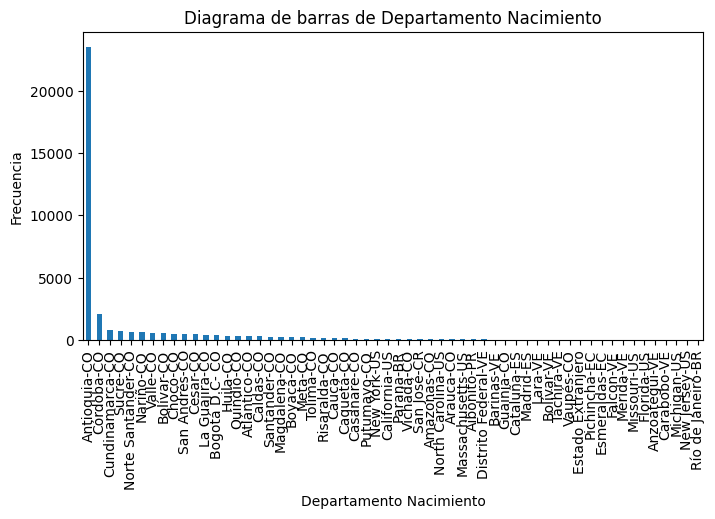

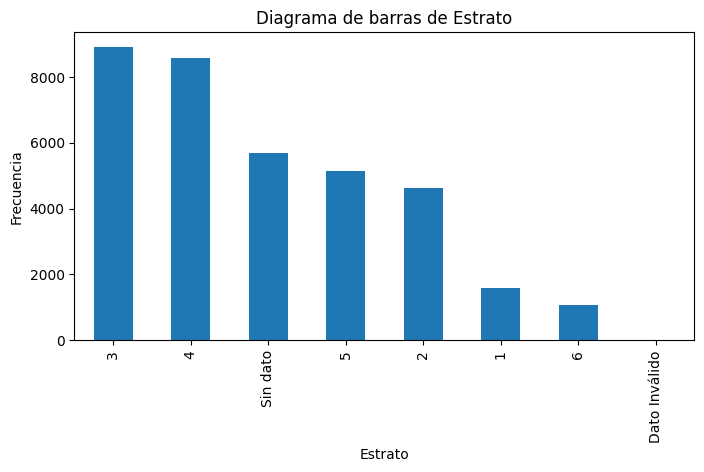

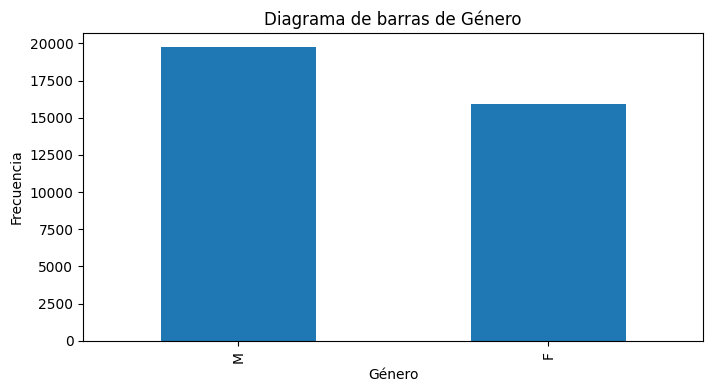

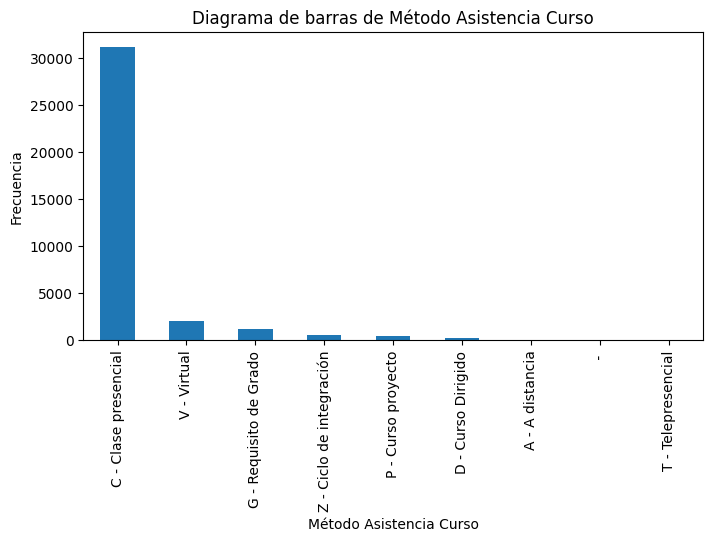

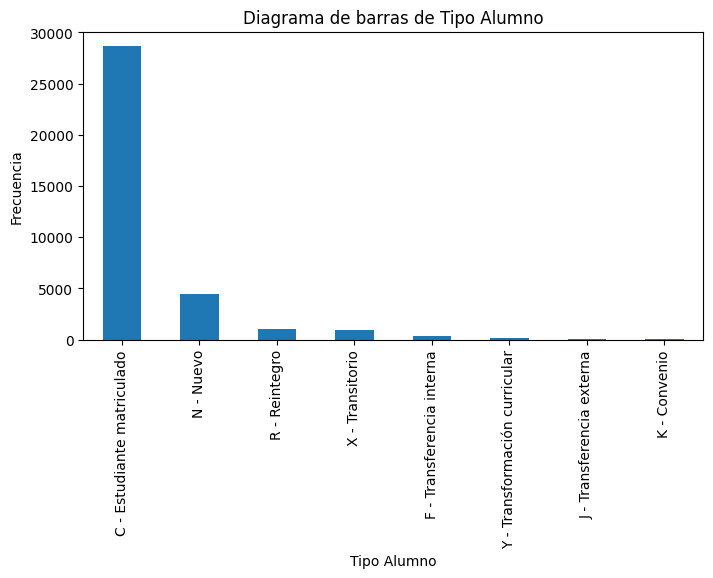

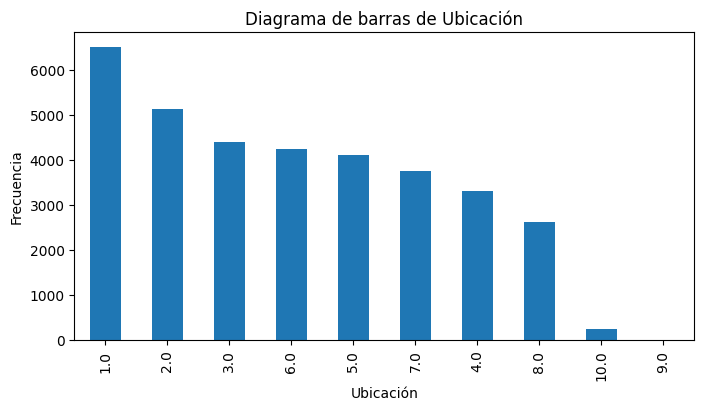

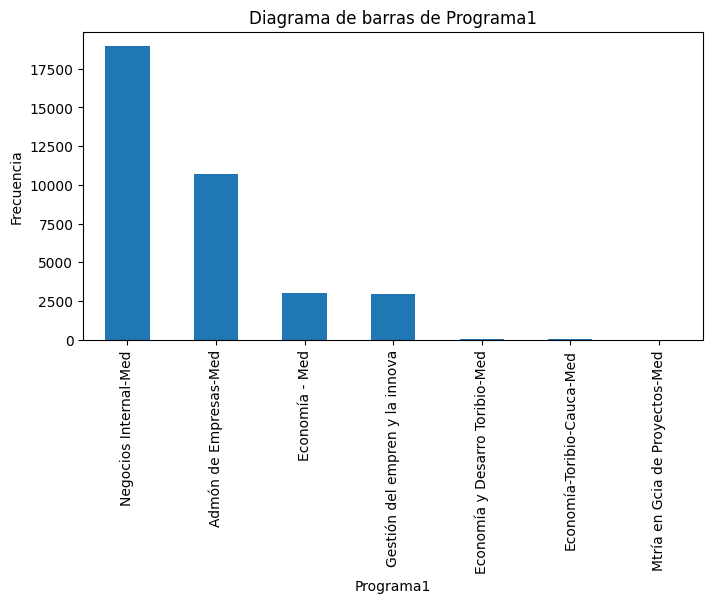

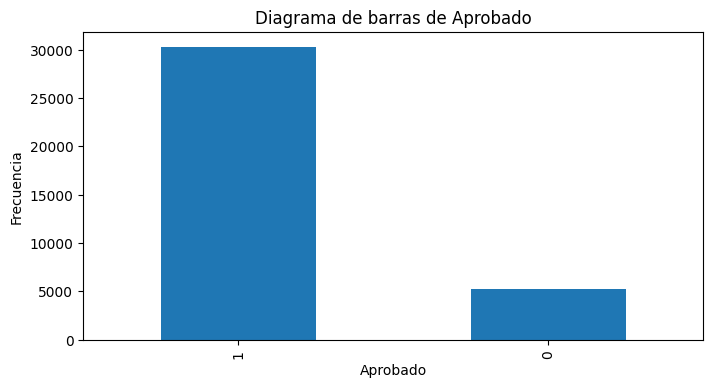

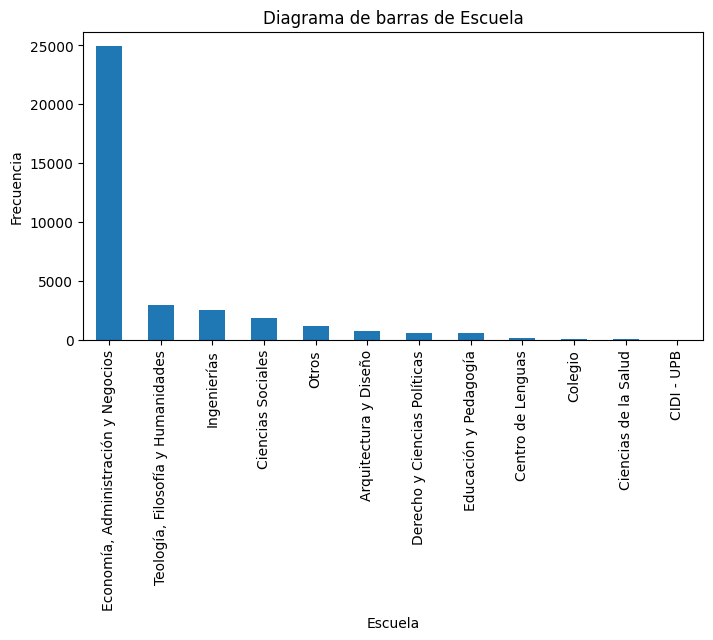

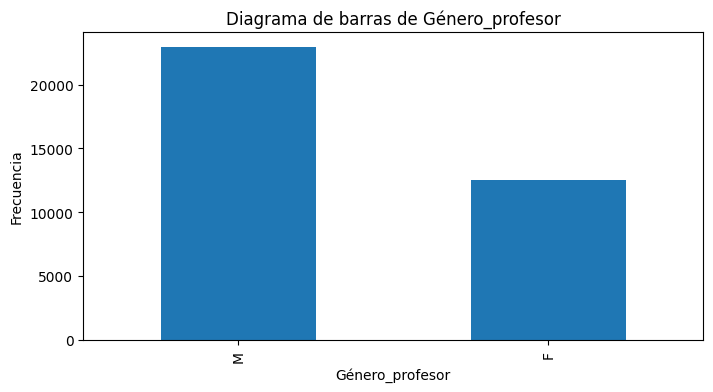

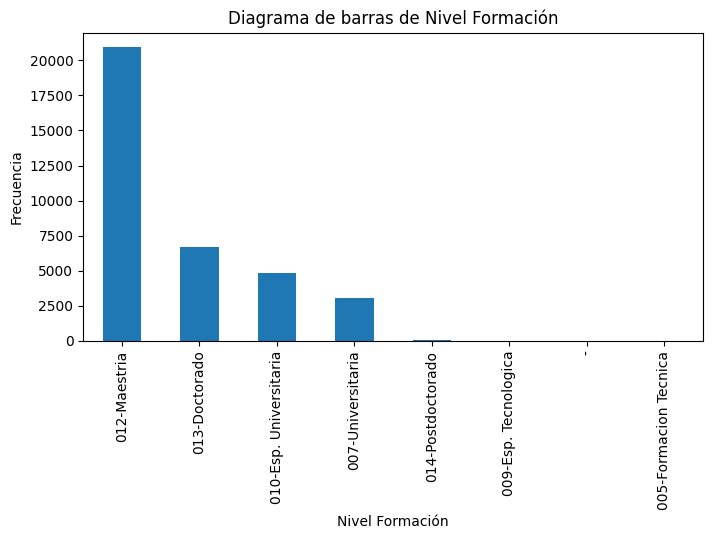

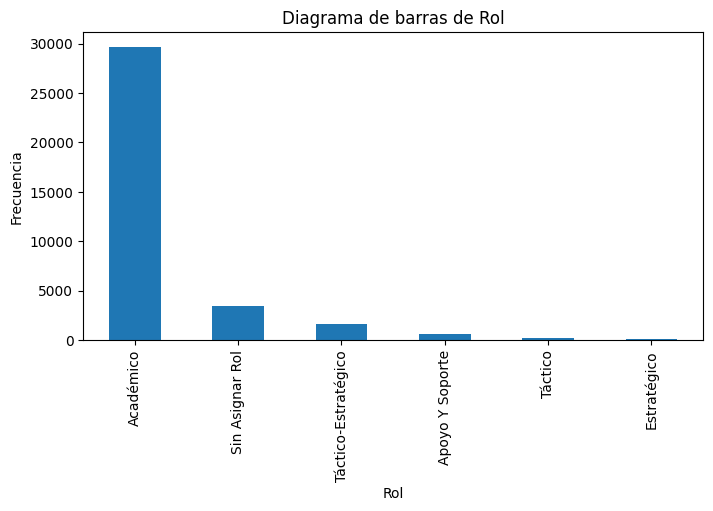

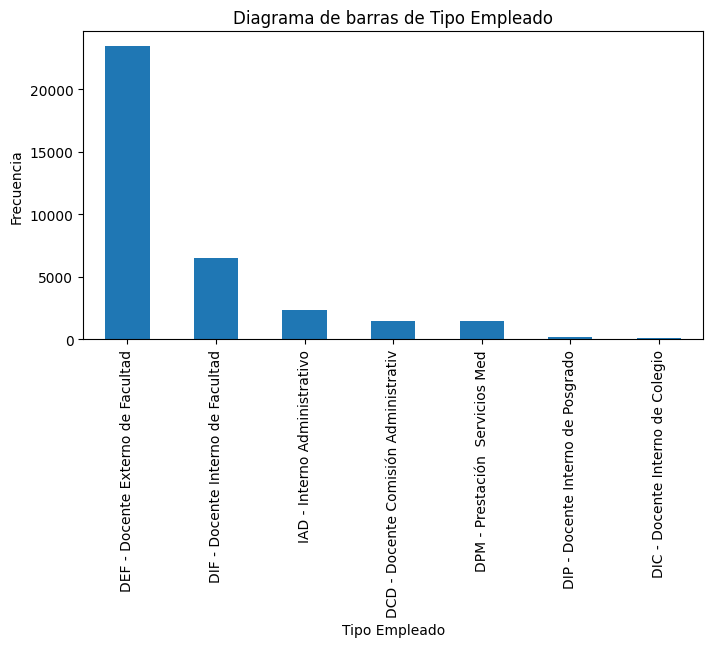

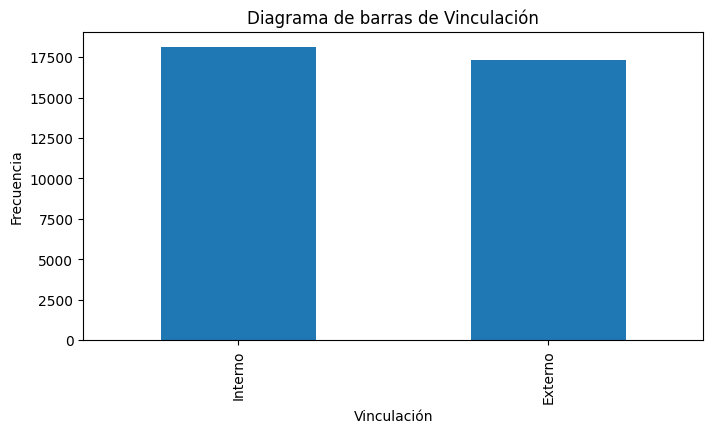

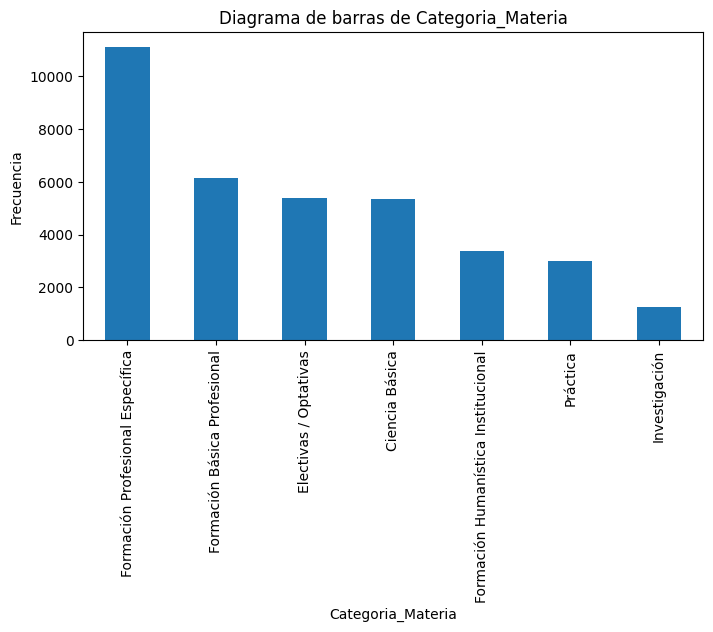

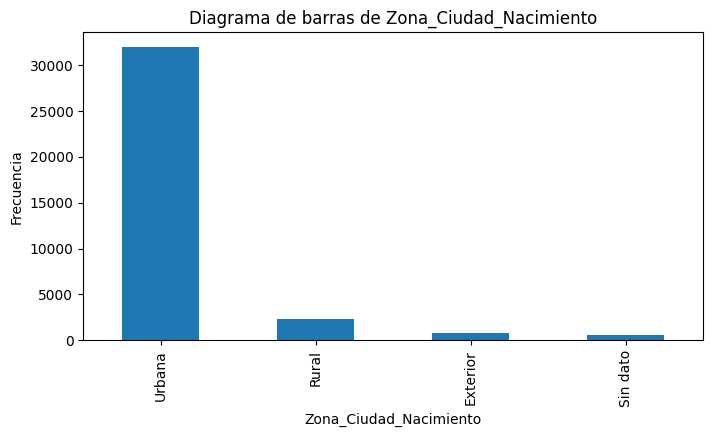

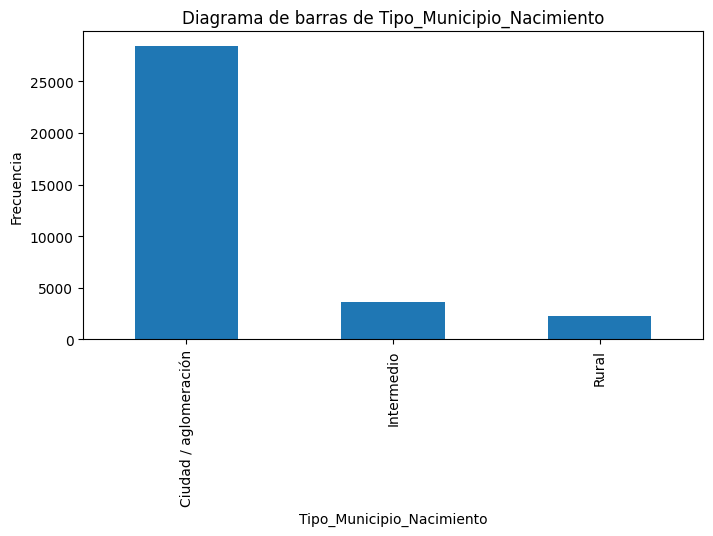

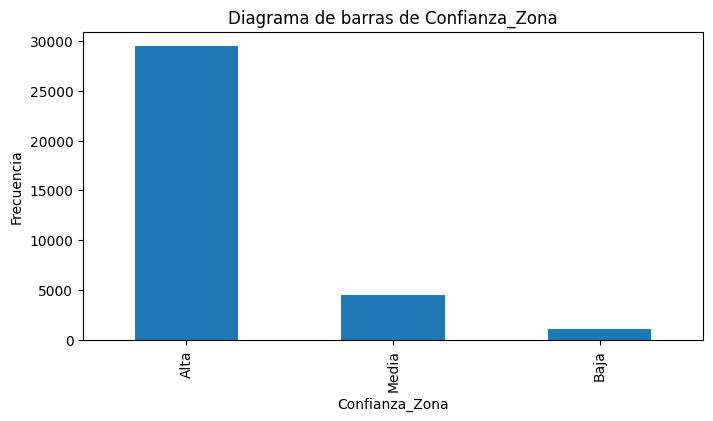

In [75]:
columnas_categoricas = df.select_dtypes(include=["category"]).columns

for col in columnas_categoricas:
    df[col].value_counts().plot(kind="bar", figsize=(8, 4))
    plt.title(f"Diagrama de barras de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Limpieza de datos atípicos

En este caso en las variables numericas obtenemos datos atípicos por variablilidad natural

In [76]:
print('Datos con atípicos por error humano')
print(df['Naturaleza Colegio'].value_counts())

df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('Sin Información',np.nan)
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('PRIVADO','NO OFICIAL')
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Naturaleza Colegio'].value_counts())

Datos con atípicos por error humano
Naturaleza Colegio
NO OFICIAL         26272
OFICIAL             7980
Sin Información     1187
PRIVADO               80
Name: count, dtype: int64

Datos corregidos
Naturaleza Colegio
NO OFICIAL    26352
OFICIAL        7980
Name: count, dtype: int64


/tmp/ipykernel_7507/679537542.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('Sin Información',np.nan)
/tmp/ipykernel_7507/679537542.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('PRIVADO','NO OFICIAL')


In [77]:
print('Datos con atípicos por error humano')
print(df['Estrato'].value_counts())


df['Estrato'] = df['Estrato'].replace('Dato Inválido',np.nan)
df['Estrato'] = df['Estrato'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Estrato'].value_counts())

Datos con atípicos por error humano
Estrato
3                8918
4                8572
Sin dato         5699
5                5150
2                4614
1                1596
6                1084
Dato Inválido       6
Name: count, dtype: int64

Datos corregidos
Estrato
3           8918
4           8572
Sin dato    5699
5           5150
2           4614
1           1596
6           1084
Name: count, dtype: int64


/tmp/ipykernel_7507/408654031.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Estrato'] = df['Estrato'].replace('Dato Inválido',np.nan)


In [78]:
print('Datos con atípicos por error humano')
print(df['Método Asistencia Curso'].value_counts())


df['Método Asistencia Curso'] = df['Método Asistencia Curso'].replace(' - ',np.nan)
df['Método Asistencia Curso'] = df['Método Asistencia Curso'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Método Asistencia Curso'].value_counts())

Datos con atípicos por error humano
Método Asistencia Curso
C - Clase presencial        31144
V - Virtual                  2005
G - Requisito de Grado       1170
Z - Ciclo de integración      578
P - Curso proyecto            401
D - Curso Dirigido            259
A - A distancia                44
 -                             33
T - Telepresencial              5
Name: count, dtype: int64

Datos corregidos
Método Asistencia Curso
C - Clase presencial        31144
V - Virtual                  2005
G - Requisito de Grado       1170
Z - Ciclo de integración      578
P - Curso proyecto            401
D - Curso Dirigido            259
A - A distancia                44
T - Telepresencial              5
Name: count, dtype: int64


/tmp/ipykernel_7507/1816271038.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Método Asistencia Curso'] = df['Método Asistencia Curso'].replace(' - ',np.nan)


In [79]:
print('Datos con atípicos por error humano')
print(df['Nivel Formación'].value_counts())


df['Nivel Formación'] = df['Nivel Formación'].replace('-',np.nan)
df['Nivel Formación'] = df['Nivel Formación'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Nivel Formación'].value_counts())

Datos con atípicos por error humano
Nivel Formación
012-Maestria              20928
013-Doctorado              6665
010-Esp. Universitaria     4828
007-Universitaria          3027
014-Postdoctorado            45
009-Esp. Tecnologica          1
-                             1
005-Formacion Tecnica         1
Name: count, dtype: int64

Datos corregidos
Nivel Formación
012-Maestria              20928
013-Doctorado              6665
010-Esp. Universitaria     4828
007-Universitaria          3027
014-Postdoctorado            45
009-Esp. Tecnologica          1
005-Formacion Tecnica         1
Name: count, dtype: int64


/tmp/ipykernel_7507/2186869929.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Nivel Formación'] = df['Nivel Formación'].replace('-',np.nan)


In [80]:
programas_validos = [
    'Negocios Internal-Med',
    'Admón de Empresas-Med',
    'Gestión del empren y la innova',
    'Economía - Med'
]

print('Antes:', len(df))

df = df[df['Programa1'].isin(programas_validos)]

df['Programa1'] = df['Programa1'].cat.remove_unused_categories()

print('Despues:', len(df))
print(df['Programa1'].value_counts())

Antes: 35639
Despues: 35572
Programa1
Negocios Internal-Med             18946
Admón de Empresas-Med             10676
Economía - Med                     3002
Gestión del empren y la innova     2948
Name: count, dtype: int64


In [81]:
print('Datos con atípicos por error humano')
print(df['Zona_Ciudad_Nacimiento'].value_counts())


df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].replace('Sin dato',np.nan)
df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Zona_Ciudad_Nacimiento'].value_counts())

Datos con atípicos por error humano
Zona_Ciudad_Nacimiento
Urbana      31991
Rural        2239
Exterior      757
Sin dato      585
Name: count, dtype: int64

Datos corregidos
Zona_Ciudad_Nacimiento
Urbana      31991
Rural        2239
Exterior      757
Name: count, dtype: int64


/tmp/ipykernel_7507/119165801.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].replace('Sin dato',np.nan)


In [82]:
df['ORIGEN_NACIMIENTO'] = np.where(
    df['Departamento Nacimiento'] == 'Antioquia-CO',
    "local",
    'foraneo'
)

df['ORIGEN_NACIMIENTO'] = np.where(
    df['Departamento Nacimiento'].isna(),
    np.nan,
    df['ORIGEN_NACIMIENTO']
)
df['ORIGEN_NACIMIENTO'] = df['ORIGEN_NACIMIENTO'].astype('category')

<Axes: xlabel='ORIGEN_NACIMIENTO'>

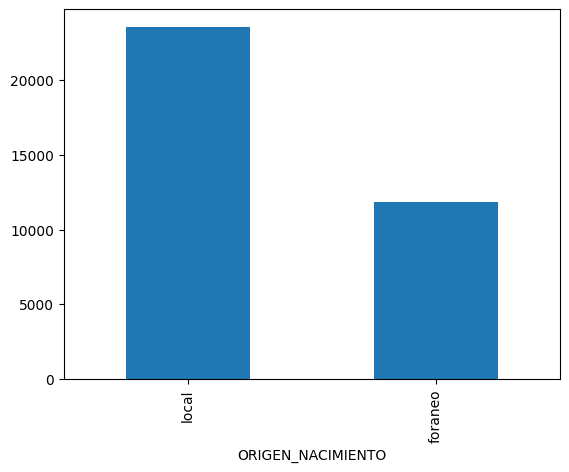

In [83]:
df['ORIGEN_NACIMIENTO'].value_counts().plot(kind='bar')

In [84]:
df['ORIGEN_COLEGIO'] = np.where(
    df['Departamento Colegio'] == 'ANTIOQUIA',
    "local",
    'foraneo'
)

df['ORIGEN_COLEGIO'] = np.where(
    df['Departamento Colegio'].isna(),
    np.nan,
    df['ORIGEN_COLEGIO']
)
df['ORIGEN_COLEGIO'] = df['ORIGEN_COLEGIO'].astype('category')

<Axes: xlabel='ORIGEN_COLEGIO'>

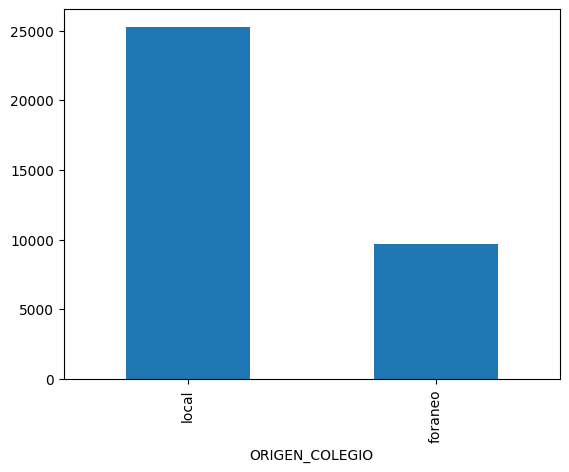

In [85]:
df['ORIGEN_COLEGIO'].value_counts().plot(kind='bar')

In [86]:
df.drop(
    columns = ['Departamento Colegio','Departamento Nacimiento'],
    inplace = True
)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35572 entries, 0 to 35638
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Año Saber11                   34585 non-null  category
 1   Semestre                      35572 non-null  category
 2   Naturaleza Colegio            34267 non-null  category
 3   Edad                          35572 non-null  float64 
 4   Estrato                       35567 non-null  category
 5   Género                        35572 non-null  category
 6   Método Asistencia Curso       35539 non-null  category
 7   Tipo Alumno                   35572 non-null  category
 8   Ubicación                     34289 non-null  category
 9   Créditos Académicos           35572 non-null  float64 
 10  Programa1                     35572 non-null  category
 11  Aprobado                      35572 non-null  category
 12  creditos_aprobados_hist       35572 non-null  float

# Limpieza de datos nulos

## Eliminación de datos faltantes en la variable objetivo

In [88]:
print('Antes:', len(df))

df = df[df['Aprobado'].notna()]

print('Despues:', len(df))
print(df['Aprobado'].value_counts())

Antes: 35572
Despues: 35572
Aprobado
1    30269
0     5303
Name: count, dtype: int64


## Eliminación de filas con más del 15% de valores faltantes

In [89]:
print('Antes:', len(df))

porcentaje_nulos_fila = df.isnull().mean(axis=1)

df = df[porcentaje_nulos_fila <= 0.15]

print('Despues:', len(df))

Antes: 35572
Despues: 35427


## Variables con más del 15% de valores faltantes

In [90]:
df.isna().mean()*100

,0
Año Saber11,2.754961
Semestre,0.000000
Naturaleza Colegio,3.666695
Edad,0.000000
Estrato,0.014114
Género,0.000000
Método Asistencia Curso,0.081858
Tipo Alumno,0.000000
Ubicación,3.607418
Créditos Académicos,0.000000


No contamos con variables com mas del 15% nulas

## Imputación de variables

Dado a que nuestras variables con datos nulos son categoricas se realiza la imputacion por la moda

In [91]:
df['Año Saber11'] = df['Año Saber11'].fillna(df['Año Saber11'].mode()[0])
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].fillna(df['Naturaleza Colegio'].mode()[0])
df['ORIGEN_COLEGIO'] = df['ORIGEN_COLEGIO'].fillna(df['ORIGEN_COLEGIO'].mode()[0])
df['ORIGEN_NACIMIENTO'] = df['ORIGEN_NACIMIENTO'].fillna(df['ORIGEN_NACIMIENTO'].mode()[0])
df['Estrato'] = df['Estrato'].fillna(df['Estrato'].mode()[0])
df['Método Asistencia Curso'] = df['Método Asistencia Curso'].fillna(df['Método Asistencia Curso'].mode()[0])
df['Ubicación'] = df['Ubicación'].fillna(df['Ubicación'].mode()[0])
df['Nivel Formación'] = df['Nivel Formación'].fillna(df['Nivel Formación'].mode()[0])
df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].fillna(df['Zona_Ciudad_Nacimiento'].mode()[0])
df['Tipo_Municipio_Nacimiento'] = df['Tipo_Municipio_Nacimiento'].fillna(df['Tipo_Municipio_Nacimiento'].mode()[0])
df['Confianza_Zona'] = df['Confianza_Zona'].fillna(df['Confianza_Zona'].mode()[0])

In [92]:
df.isna().mean()*100

,0
Año Saber11,0.0
Semestre,0.0
Naturaleza Colegio,0.0
Edad,0.0
Estrato,0.0
Género,0.0
Método Asistencia Curso,0.0
Tipo Alumno,0.0
Ubicación,0.0
Créditos Académicos,0.0


# Análisis de correlaciones

In [93]:
df_corr = df.drop(columns=["Título Curso","Aprobado"], errors="ignore").copy()

cat_cols = df_corr.select_dtypes(include=["object", "string", "category"]).columns

partes = [df_corr.drop(columns=cat_cols)]
for c in cat_cols:
    n = df_corr[c].nunique(dropna=True)
    partes.append(pd.get_dummies(df_corr[c], prefix=c, drop_first=(n == 2), dtype=int))

df_final = pd.concat(partes, axis=1)
matriz_correlacion = df_final.astype("float64").corr()
matriz_correlacion

,Edad,Créditos Académicos,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Edad_profesor,Año Saber11_2014.0,Año Saber11_2015.0,Año Saber11_2016.0,Año Saber11_2017.0,Año Saber11_2018.0,Año Saber11_2019.0,Año Saber11_2020.0,Año Saber11_2021.0,Año Saber11_2022.0,Año Saber11_2023.0,Año Saber11_2024.0,Año Saber11_2025.0,Semestre_20,Naturaleza Colegio_OFICIAL,Estrato_1,Estrato_2,Estrato_3,Estrato_4,Estrato_5,Estrato_6,Estrato_Sin dato,Género_M,Método Asistencia Curso_A - A distancia,Método Asistencia Curso_C - Clase presencial,Método Asistencia Curso_D - Curso Dirigido,Método Asistencia Curso_G - Requisito de Grado,Método Asistencia Curso_P - Curso proyecto,Método Asistencia Curso_T - Telepresencial,Método Asistencia Curso_V - Virtual,Método Asistencia Curso_Z - Ciclo de integración,Tipo Alumno_C - Estudiante matriculado,Tipo Alumno_F - Transferencia interna,Tipo Alumno_J - Transferencia externa,Tipo Alumno_K - Convenio,Tipo Alumno_N - Nuevo,Tipo Alumno_R - Reintegro,Tipo Alumno_X - Transitorio,Tipo Alumno_Y - Transformación curricular,Ubicación_1.0,Ubicación_2.0,Ubicación_3.0,Ubicación_4.0,Ubicación_5.0,Ubicación_6.0,Ubicación_7.0,Ubicación_8.0,Ubicación_9.0,Ubicación_10.0,Programa1_Admón de Empresas-Med,Programa1_Economía - Med,Programa1_Gestión del empren y la innova,Programa1_Negocios Internal-Med,Escuela_Arquitectura y Diseño,Escuela_CIDI - UPB,Escuela_Centro de Lenguas,Escuela_Ciencias Sociales,Escuela_Ciencias de la Salud,Escuela_Colegio,Escuela_Derecho y Ciencias Políticas,"Escuela_Economía, Administración y Negocios",Escuela_Educación y Pedagogía,Escuela_Ingenierías,Escuela_Otros,"Escuela_Teología, Filosofía y Humanidades",Género_profesor_M,Nivel Formación_005-Formacion Tecnica,Nivel Formación_007-Universitaria,Nivel Formación_009-Esp. Tecnologica,Nivel Formación_010-Esp. Universitaria,Nivel Formación_012-Maestria,Nivel Formación_013-Doctorado,Nivel Formación_014-Postdoctorado,Rol_Académico,Rol_Apoyo Y Soporte,Rol_Estratégico,Rol_Sin Asignar Rol,Rol_Táctico,Rol_Táctico-Estratégico,Tipo Empleado_DCD - Docente Comisión Administrativ,Tipo Empleado_DEF - Docente Externo de Facultad,Tipo Empleado_DIC - Docente Interno de Colegio,Tipo Empleado_DIF - Docente Interno de Facultad,Tipo Empleado_DIP - Docente Interno de Posgrado,Tipo Empleado_DPM - Prestación Servicios Med,Tipo Empleado_IAD - Interno Administrativo,Vinculación_Interno,Categoria_Materia_Ciencia Básica,Categoria_Materia_Electivas / Optativas,Categoria_Materia_Formación Básica Profesional,Categoria_Materia_Formación Humanística Institucional,Categoria_Materia_Formación Profesional Específica,Categoria_Materia_Investigación,Categoria_Materia_Práctica,Zona_Ciudad_Nacimiento_Exterior,Zona_Ciudad_Nacimiento_Rural,Zona_Ciudad_Nacimiento_Urbana,Tipo_Municipio_Nacimiento_Ciudad / aglomeración,Tipo_Municipio_Nacimiento_Intermedio,Tipo_Municipio_Nacimiento_Rural,Confianza_Zona_Alta,Confianza_Zona_Baja,Confianza_Zona_Media,ORIGEN_NACIMIENTO_local,ORIGEN_COLEGIO_local
Edad,1.000000,0.053606,0.347516,0.216055,0.240783,0.380448,0.119976,0.005094,0.618419,0.102244,0.042603,-0.029622,0.168290,0.163890,0.218361,0.173275,0.152418,0.066817,0.121989,-0.130999,-0.145143,-0.178817,-0.191173,-0.124933,-0.058737,0.018379,0.002213,-0.072925,-0.063125,-0.016098,0.025707,0.055929,0.108555,0.102243,NaN,-0.190853,0.109536,0.156547,0.046543,-0.008857,0.054183,0.068312,0.173523,-0.031091,0.001436,-0.020097,-0.289737,0.170221,0.013911,0.022177,-0.300700,-0.202741,-0.073898,0.001966,0.075637,0.154708,0.205965,0.267106,0.014619,0.154978,0.141773,0.031995,-0.004523,-0.145587,0.032347,0.003413,0.013236,-0.015213,-0.003503,0.002185,-0.009530,0.006523,-0.056658,-0.032013,0.025417,0.023912,0.016498,-0.001854,0.008580,-0.003610,-0.011249,0.027103,-0.029716,-0.006684,-0.111161,0.030882,0.010150,0.082037,-0.005061,0.062311,0.058636,-0.071444,0.021179

In [94]:
matriz_correlacion.to_excel('correlaciones_predictoras.xlsx',index = True)

Variables con |correlación| >= 0.8: 9


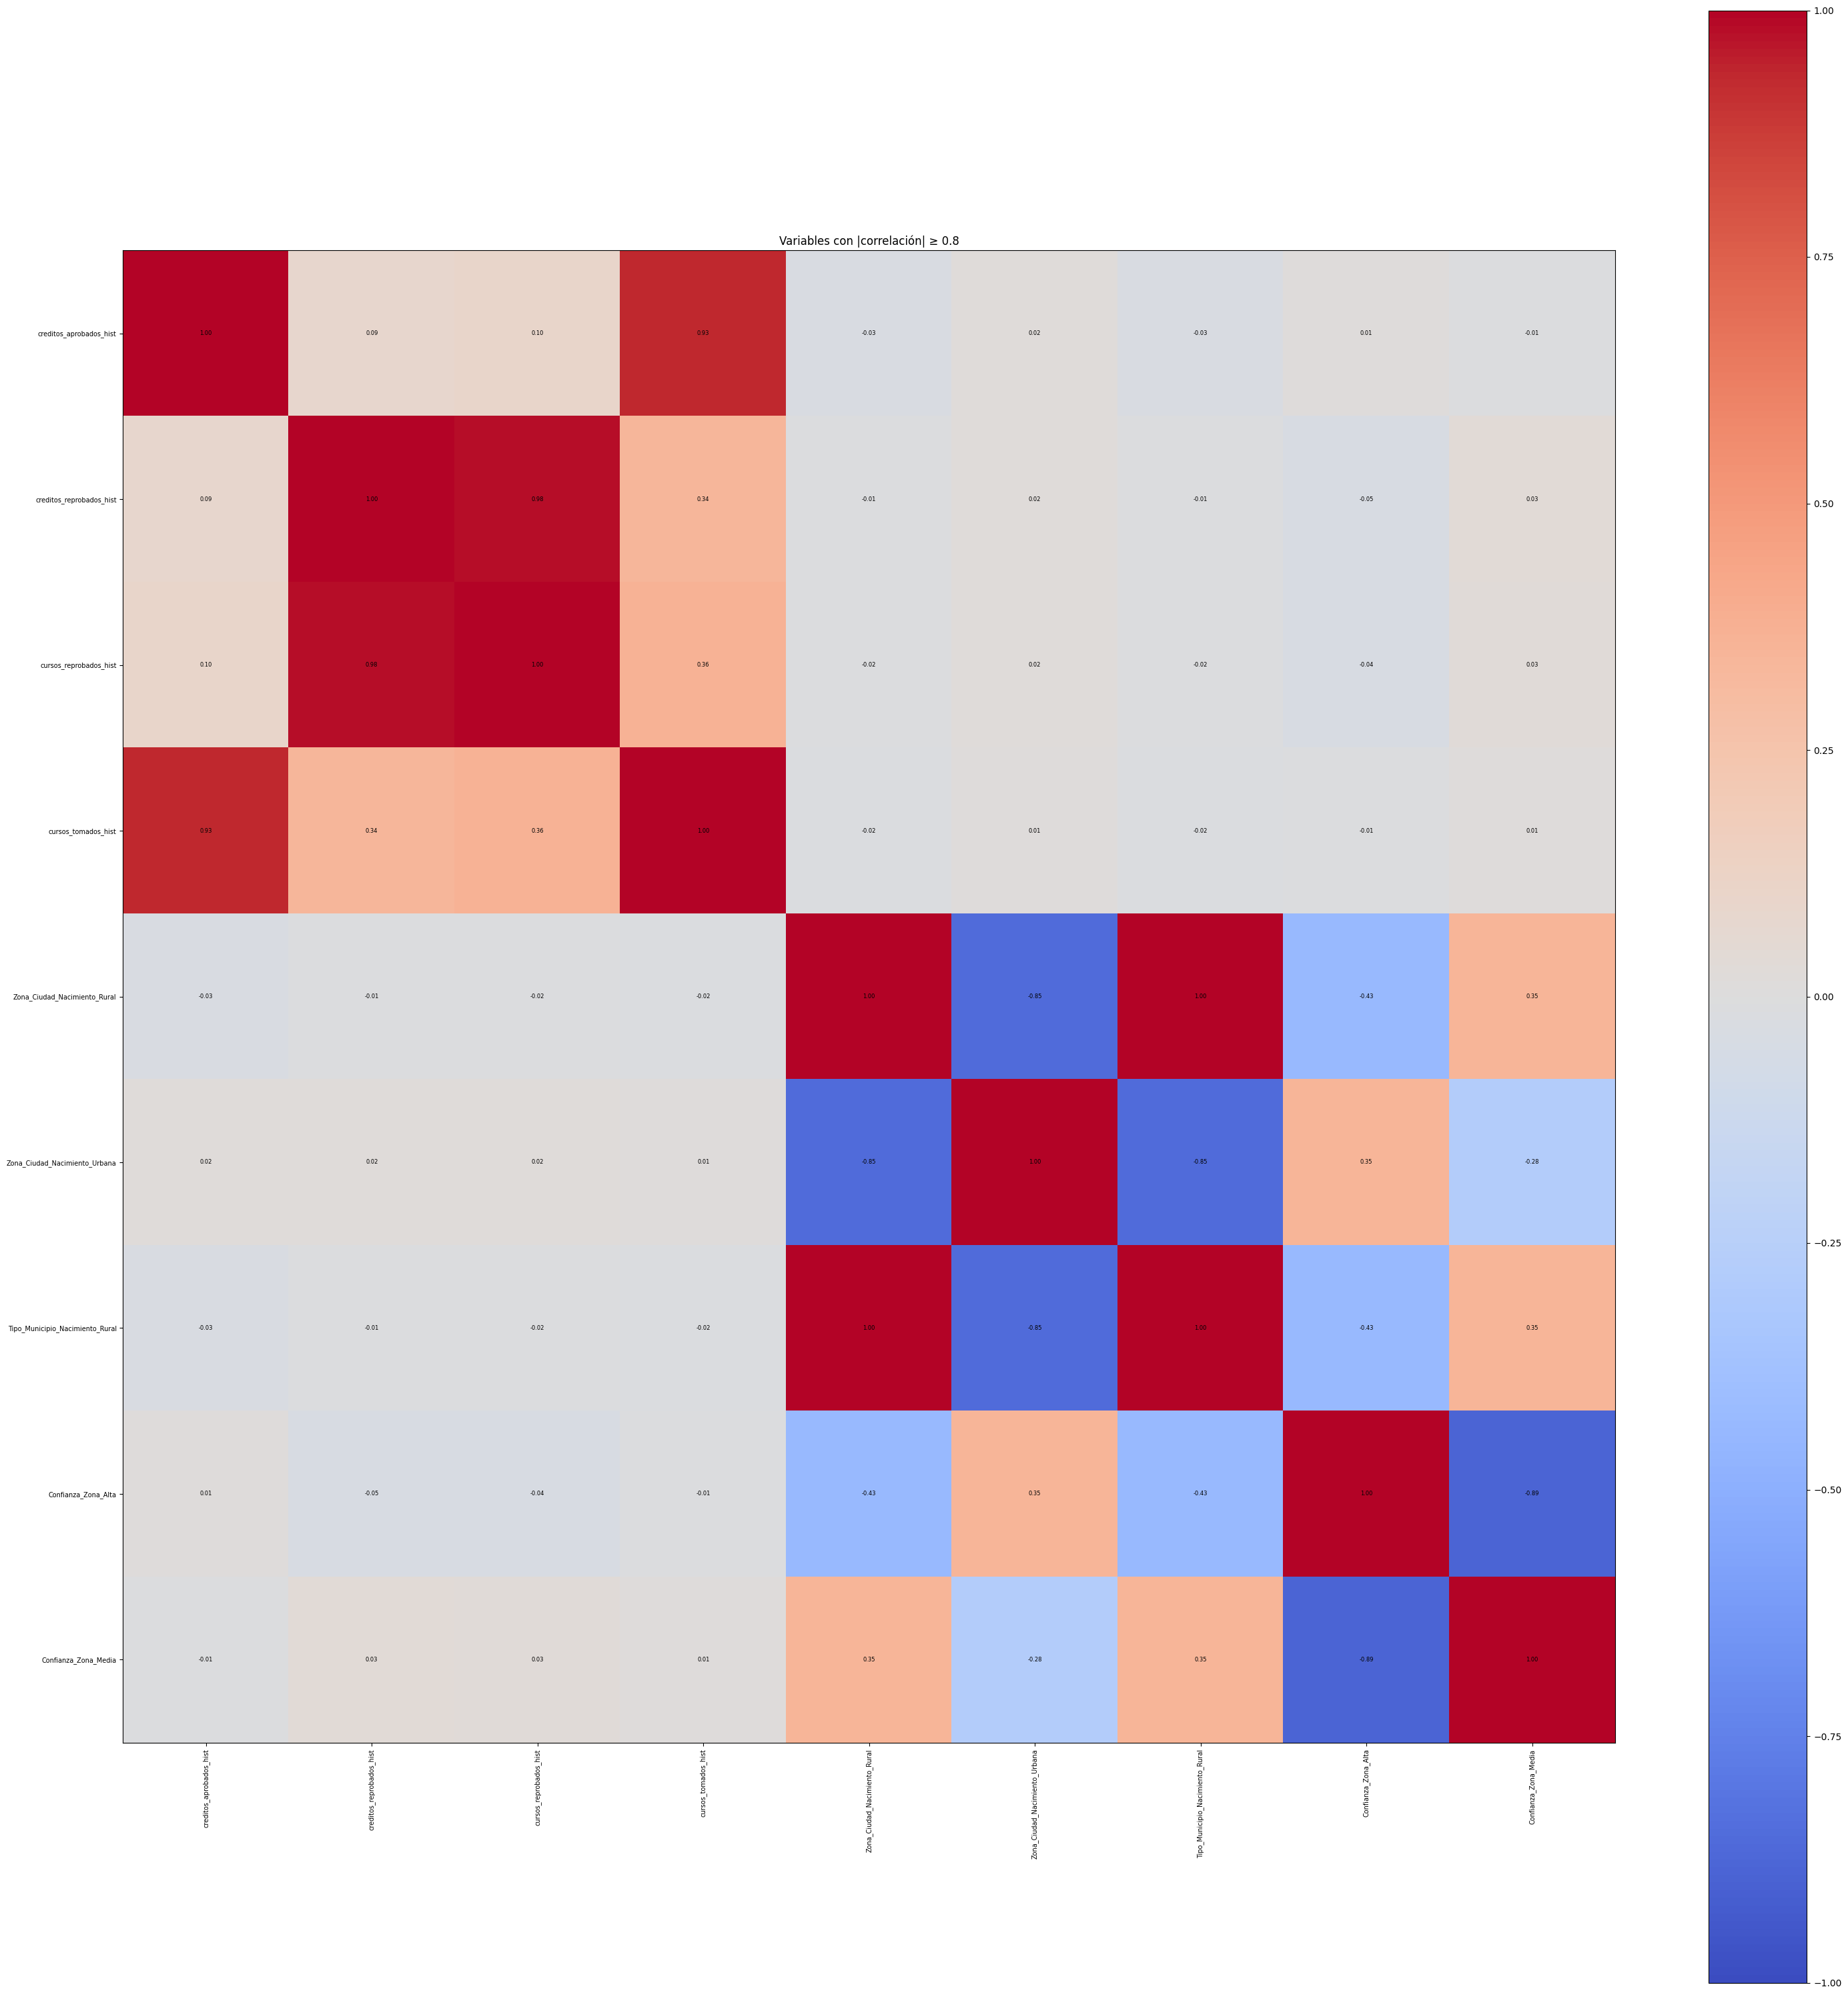

In [95]:
umbral = 0.8

matriz_correlacion = matriz_correlacion.dropna(how="all").dropna(axis=1, how="all")

mask_diag = np.eye(len(matriz_correlacion), dtype=bool)
corr_abs = matriz_correlacion.abs().mask(mask_diag)

cols_relevantes = corr_abs.columns[(corr_abs >= umbral).any()]
sub = matriz_correlacion.loc[cols_relevantes, cols_relevantes]

k = len(sub)
print(f"Variables con |correlación| >= {umbral}: {k}")

plt.figure(figsize=(30,30))
plt.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(k), sub.columns, rotation=90, fontsize=7)
plt.yticks(range(k), sub.columns, fontsize=7)

if k <= 40:
    for i in range(k):
        for j in range(k):
            plt.text(j, i, f"{sub.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

plt.title(f"Variables con |correlación| ≥ {umbral}")
plt.tight_layout()
plt.show()

Al analizar la matriz de correlación de las variables numéricas históricas, se identificaron dos pares de variables con correlación muy alta (superior a 0.8): creditos_reprobados_hist con cursos_reprobados_hist (0.98) y creditos_aprobados_hist con cursos_tomados_hist (0.93), además de un tercer par en el límite entre tasa_aprobacion_hist y promedio_notas_hist (0.80). Esta alta correlación es esperable, ya que dentro de cada par ambas variables capturan esencialmente el mismo fenómeno académico del estudiante (créditos reprobados y cursos reprobados, o créditos aprobados y cursos tomados) medido en unidades distintas, lo que genera redundancia de información.

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


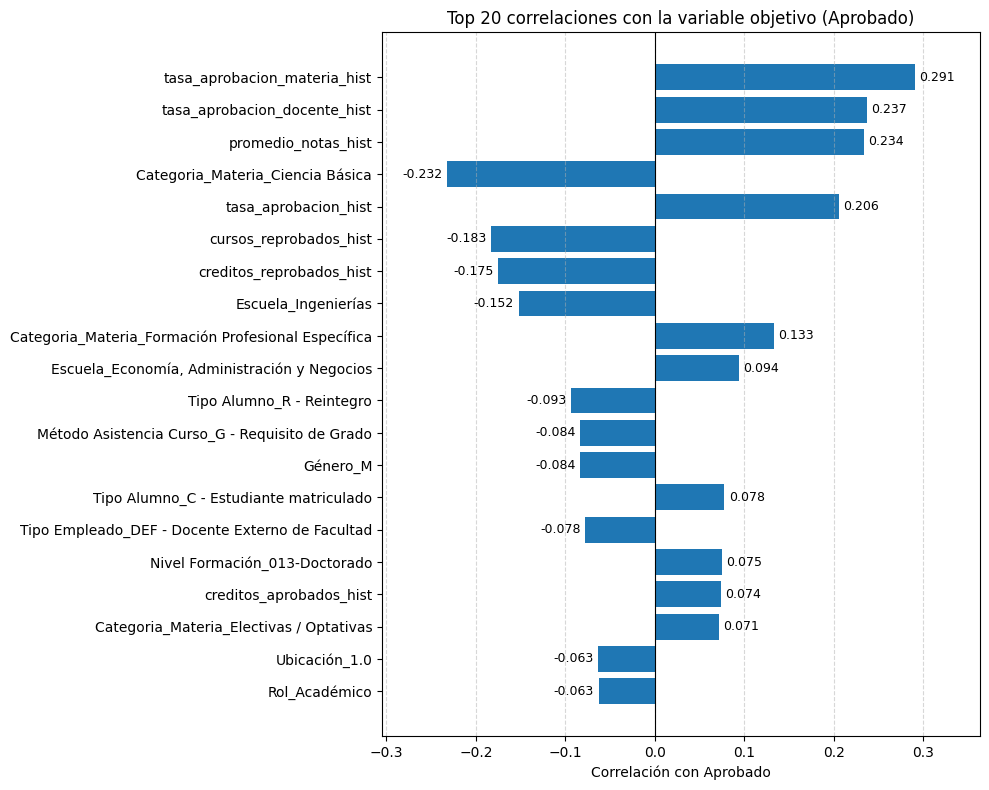

In [96]:
correlacion_aprobado = df_final.astype("float64").corrwith(df["Aprobado"].astype(float))
correlacion_aprobado = correlacion_aprobado.dropna()


top20 = correlacion_aprobado.reindex(
    correlacion_aprobado.abs().sort_values(ascending=False).index
).head(20)


plt.figure(figsize=(10, 8))
bars = plt.barh(top20.index[::-1], top20.values[::-1], )
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlación con Aprobado")
plt.title("Top 20 correlaciones con la variable objetivo (Aprobado)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

margen = top20.abs().max() * 0.25
plt.xlim(top20.min() - margen, top20.max() + margen)

for bar in bars:
    ancho = bar.get_width()
    offset = 0.005 if ancho >= 0 else -0.005
    ha = "left" if ancho >= 0 else "right"
    plt.text(
        ancho + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{ancho:.3f}",
        va="center",
        ha=ha,
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [97]:
CORRELACIONES_BAJAS =[
    'Confianza_Zona','Zona_Ciudad_Nacimiento','Género_profesor','num_periodos_cursados','Semestre','cursos_tomados_hist',
    'cursos_reprobados_hist'
]

df.drop(
    columns = CORRELACIONES_BAJAS,
    inplace = True
)

Variables con |correlación| >= 0.8: 0


/tmp/ipykernel_7507/540424243.py:27: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)
/tmp/ipykernel_7507/540424243.py:27: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)


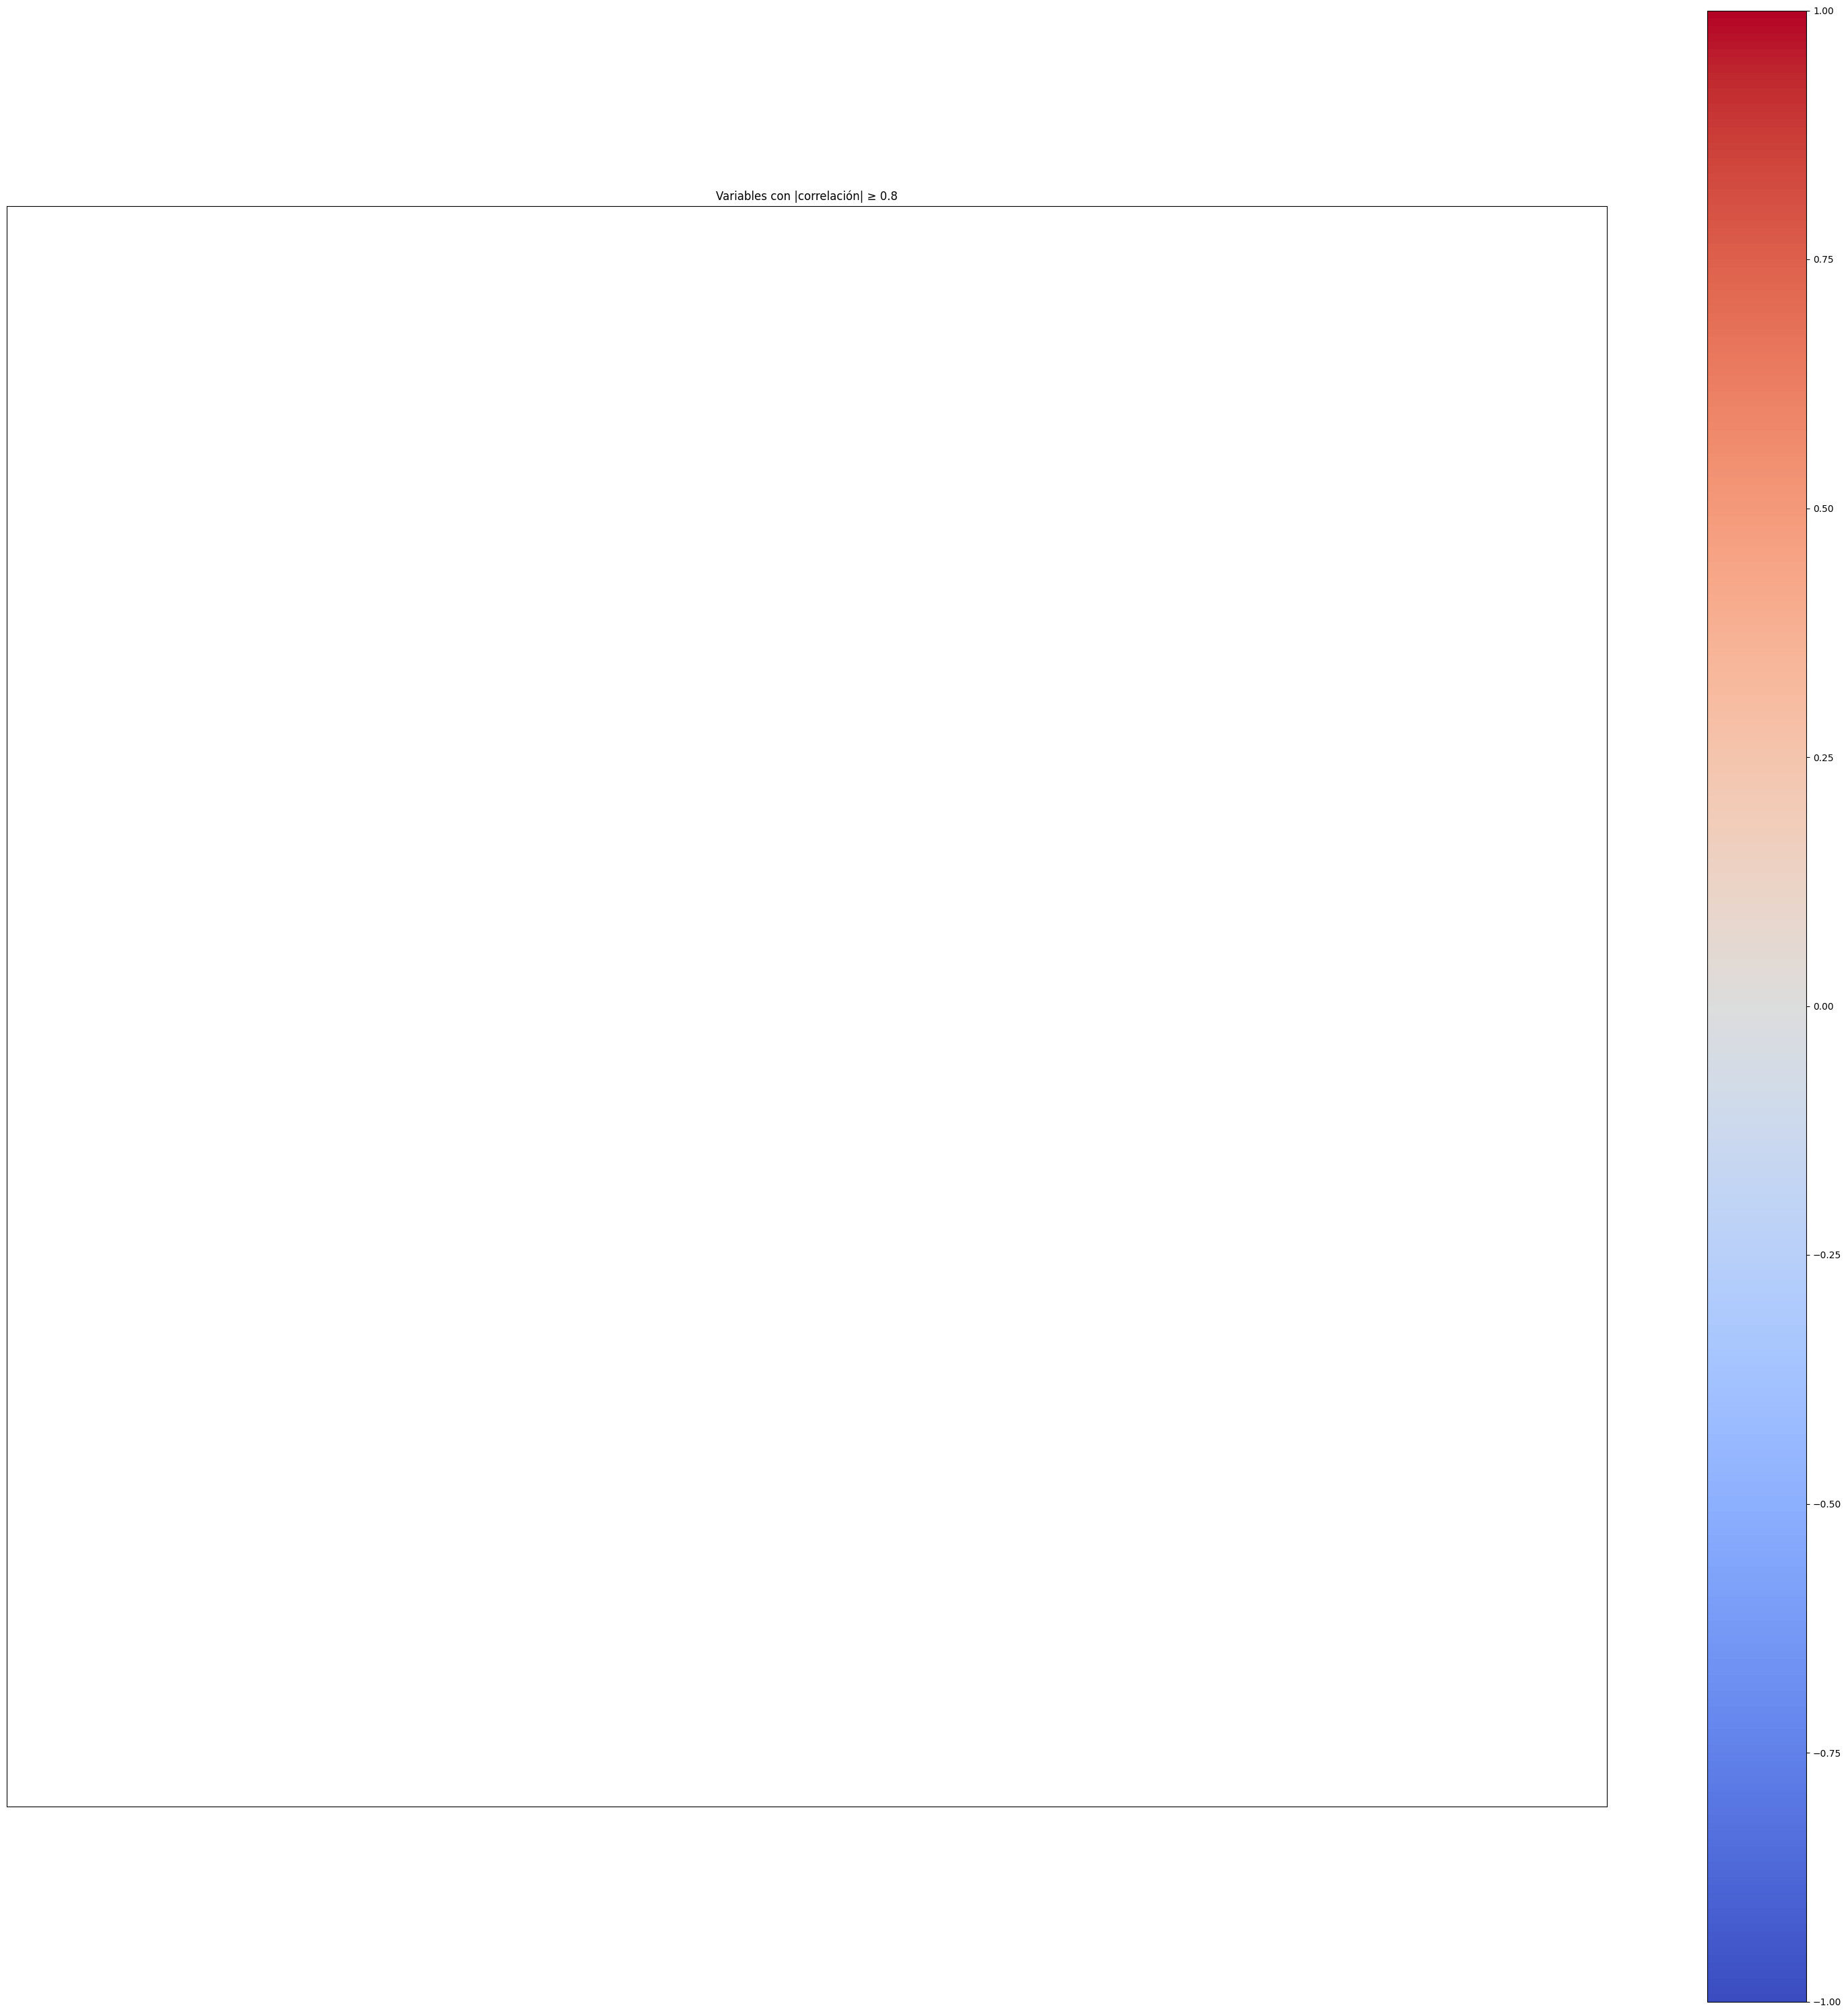

In [98]:
df_corr = df.drop(columns=["Título Curso","Aprobado"], errors="ignore").copy()

cat_cols = df_corr.select_dtypes(include=["object", "string", "category"]).columns

partes = [df_corr.drop(columns=cat_cols)]
for c in cat_cols:
    n = df_corr[c].nunique(dropna=True)
    partes.append(pd.get_dummies(df_corr[c], prefix=c, drop_first=(n == 2), dtype=int))

df_final = pd.concat(partes, axis=1)
matriz_correlacion = df_final.astype("float64").corr()

umbral = 0.8

matriz_correlacion = matriz_correlacion.dropna(how="all").dropna(axis=1, how="all")

mask_diag = np.eye(len(matriz_correlacion), dtype=bool)
corr_abs = matriz_correlacion.abs().mask(mask_diag)

cols_relevantes = corr_abs.columns[(corr_abs >= umbral).any()]
sub = matriz_correlacion.loc[cols_relevantes, cols_relevantes]

k = len(sub)
print(f"Variables con |correlación| >= {umbral}: {k}")

plt.figure(figsize=(30,30))
plt.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(k), sub.columns, rotation=90, fontsize=7)
plt.yticks(range(k), sub.columns, fontsize=7)

if k <= 40:
    for i in range(k):
        for j in range(k):
            plt.text(j, i, f"{sub.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

plt.title(f"Variables con |correlación| ≥ {umbral}")
plt.tight_layout()
plt.show()

# Ingeniería de características

In [99]:
df_predictiva = df.copy()

## Predictiva

<Axes: xlabel='Aprobado'>

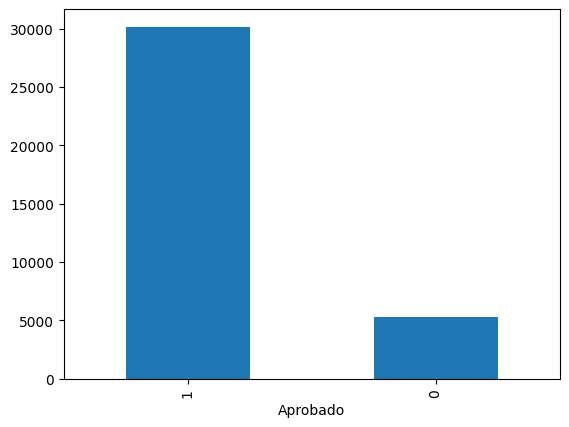

In [100]:
df_predictiva['Aprobado'].value_counts().plot(kind='bar')

In [101]:
df_predictiva.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35427 entries, 0 to 35638
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Año Saber11                   35427 non-null  category
 1   Naturaleza Colegio            35427 non-null  category
 2   Edad                          35427 non-null  float64 
 3   Estrato                       35427 non-null  category
 4   Género                        35427 non-null  category
 5   Método Asistencia Curso       35427 non-null  category
 6   Tipo Alumno                   35427 non-null  category
 7   Ubicación                     35427 non-null  category
 8   Créditos Académicos           35427 non-null  float64 
 9   Programa1                     35427 non-null  category
 10  Aprobado                      35427 non-null  category
 11  creditos_aprobados_hist       35427 non-null  float64 
 12  creditos_reprobados_hist      35427 non-null  float

No se puede balancear al 50% porque se tendrian mas datos de mentira que datos reales

In [102]:
from imblearn.over_sampling import SMOTE, SMOTENC

X = df_predictiva.drop('Aprobado', axis = 1)
Y = df_predictiva['Aprobado']
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35427 entries, 0 to 35638
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Año Saber11                   35427 non-null  category
 1   Naturaleza Colegio            35427 non-null  category
 2   Edad                          35427 non-null  float64 
 3   Estrato                       35427 non-null  category
 4   Género                        35427 non-null  category
 5   Método Asistencia Curso       35427 non-null  category
 6   Tipo Alumno                   35427 non-null  category
 7   Ubicación                     35427 non-null  category
 8   Créditos Académicos           35427 non-null  float64 
 9   Programa1                     35427 non-null  category
 10  creditos_aprobados_hist       35427 non-null  float64 
 11  creditos_reprobados_hist      35427 non-null  float64 
 12  tasa_aprobacion_hist          35427 non-null  float

<Axes: xlabel='Aprobado'>

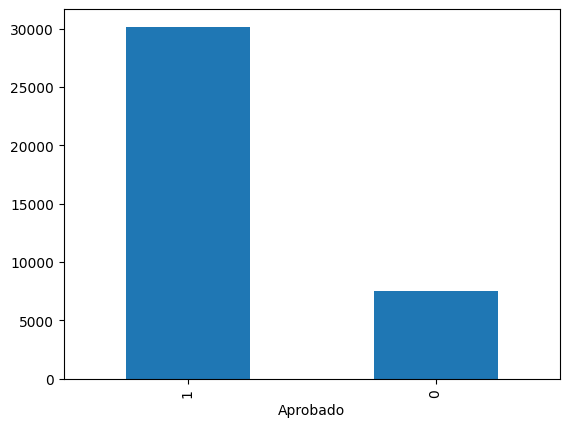

In [103]:
smote = SMOTENC(
    random_state=42,
    k_neighbors=2,
    sampling_strategy=0.25,
    categorical_features=[0, 1, 3, 4, 5, 6, 7, 9, 16, 18, 19, 20, 21, 22, 23, 24, 25]
)
X_smote, y_smote = smote.fit_resample(X, Y)

# Creamos un dataframe con los resultados (X_smote, y_smote)
df_predictiva  = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)
df_predictiva['Aprobado']=y_smote
df_predictiva['Aprobado'].value_counts().plot(kind='bar')

In [104]:
cat_cols = df_predictiva.select_dtypes(include=["category"]).columns

partes = [df_predictiva.drop(columns=cat_cols)]

for c in cat_cols:
    if c != 'Aprobado':
        n = df_predictiva[c].nunique(dropna=True)
        partes.append(pd.get_dummies(df_predictiva[c], prefix=c, drop_first=(n == 2), dtype=int))
    else:
        partes.append(df_predictiva[c])

df_predictiva = pd.concat(partes, axis=1)

In [105]:
df_predictiva.sample(2)

,Edad,Créditos Académicos,creditos_aprobados_hist,creditos_reprobados_hist,tasa_aprobacion_hist,promedio_notas_hist,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Edad_profesor,Año Saber11_2014.0,Año Saber11_2015.0,Año Saber11_2016.0,Año Saber11_2017.0,Año Saber11_2018.0,Año Saber11_2019.0,Año Saber11_2020.0,Año Saber11_2021.0,Año Saber11_2022.0,Año Saber11_2023.0,Año Saber11_2024.0,Año Saber11_2025.0,Naturaleza Colegio_OFICIAL,Estrato_1,Estrato_2,Estrato_3,Estrato_4,Estrato_5,Estrato_6,Estrato_Sin dato,Género_M,Método Asistencia Curso_A - A distancia,Método Asistencia Curso_C - Clase presencial,Método Asistencia Curso_D - Curso Dirigido,Método Asistencia Curso_G - Requisito de Grado,Método Asistencia Curso_P - Curso proyecto,Método Asistencia Curso_T - Telepresencial,Método Asistencia Curso_V - Virtual,Método Asistencia Curso_Z - Ciclo de integración,Tipo Alumno_C - Estudiante matriculado,Tipo Alumno_F - Transferencia interna,Tipo Alumno_J - Transferencia externa,Tipo Alumno_K - Convenio,Tipo Alumno_N - Nuevo,Tipo Alumno_R - Reintegro,Tipo Alumno_X - Transitorio,Tipo Alumno_Y - Transformación curricular,Ubicación_1.0,Ubicación_2.0,Ubicación_3.0,Ubicación_4.0,Ubicación_5.0,Ubicación_6.0,Ubicación_7.0,Ubicación_8.0,Ubicación_9.0,Ubicación_10.0,Programa1_Admón de Empresas-Med,Programa1_Economía - Med,Programa1_Gestión del empren y la innova,Programa1_Negocios Internal-Med,Escuela_Arquitectura y Diseño,Escuela_CIDI - UPB,Escuela_Centro de Lenguas,Escuela_Ciencias Sociales,Escuela_Ciencias de la Salud,Escuela_Colegio,Escuela_Derecho y Ciencias Políticas,"Escuela_Economía, Administración y Negocios",Escuela_Educación y Pedagogía,Escuela_Ingenierías,Escuela_Otros,"Escuela_Teología, Filosofía y Humanidades",Nivel Formación_005-Formacion Tecnica,Nivel Formación_007-Universitaria,Nivel Formación_009-Esp. Tecnologica,Nivel Formación_010-Esp. Universitaria,Nivel Formación_012-Maestria,Nivel Formación_013-Doctorado,Nivel Formación_014-Postdoctorado,Rol_Académico,Rol_Apoyo Y Soporte,Rol_Estratégico,Rol_Sin Asignar Rol,Rol_Táctico,Rol_Táctico-Estratégico,Tipo Empleado_DCD - Docente Comisión Administrativ,Tipo Empleado_DEF - Docente Externo de Facultad,Tipo Empleado_DIC - Docente Interno de Colegio,Tipo Empleado_DIF - Docente Interno de Facultad,Tipo Empleado_DIP - Docente Interno de Posgrado,Tipo Empleado_DPM - Prestación Servicios Med,Tipo Empleado_IAD - Interno Administrativo,Vinculación_Interno,Categoria_Materia_Ciencia Básica,Categoria_Materia_Electivas / Optativas,Categoria_Materia_Formación Básica Profesional,Categoria_Materia_Formación Humanística Institucional,Categoria_Materia_Formación Profesional Específica,Categoria_Materia_Investigación,Categoria_Materia_Práctica,Tipo_Municipio_Nacimiento_Ciudad / aglomeración,Tipo_Municipio_Nacimiento_Intermedio,Tipo_Municipio_Nacimiento_Rural,ORIGEN_NACIMIENTO_local,ORIGEN_COLEGIO_local,Aprobado
23780,19.0,3.000000,54.0,0.0,1.000000,4.401818,0.895062,0.875000,48.000000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,1
35655,26.0,3.008874,91.0,44.0,0.587302,2.640794,0.710288,0.853435,37.955632,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [106]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df_predictiva['Aprobado'] = labelencoder.fit_transform(df_predictiva['Aprobado'])
print(df_predictiva['Aprobado'].value_counts())
print(df_predictiva['Aprobado'])

Aprobado
1    30143
0     7535
Name: count, dtype: int64
0        1
1        1
2        1
3        1
4        0
        ..
37673    0
37674    0
37675    0
37676    0
37677    0
Name: Aprobado, Length: 37678, dtype: int64


In [107]:
#Se separa variables predictoras y objetivo
X = df_predictiva.drop('Aprobado', axis = 1)
Y = df_predictiva['Aprobado']
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37678 entries, 0 to 37677
Columns: 105 entries, Edad to ORIGEN_COLEGIO_local
dtypes: float64(9), int64(96)
memory usage: 30.2 MB


In [108]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
col_num = df_predictiva.select_dtypes(include=["float64"]).columns

min_max_scaler.fit(X[col_num])

X[col_num]= min_max_scaler.transform(X[col_num])


# Entrenamiento de modelos predictivos

In [109]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold

scoring=('f1_macro', 'accuracy','precision_macro', 'recall_macro')
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## KNN

In [ ]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# scoring (tupla) se definió en la celda de Validación Cruzada.
scoring_extendido = {m: m for m in scoring}

scoring_extendido.update({
    'precision_0': make_scorer(precision_score, pos_label=0),
    'recall_0':    make_scorer(recall_score, pos_label=0),
    'f1_0':        make_scorer(f1_score, pos_label=0),
    'precision_1': make_scorer(precision_score, pos_label=1),
    'recall_1':    make_scorer(recall_score, pos_label=1),
    'f1_1':        make_scorer(f1_score, pos_label=1),
})

knn = []

for k in range(1, 18):
    model_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    scores = cross_validate(
        model_knn, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['k'] = k
    knn.append(promedio)

tabla_completa_knn = pd.DataFrame(knn)
cols = ['k'] + [c for c in tabla_completa_knn.columns if c != 'k']
tabla_completa_knn = tabla_completa_knn[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['k'] + [c for c in tabla_completa_knn.columns if 'macro' in c or c == 'accuracy'
                         or c in ['fit_time', 'score_time']]
tabla_resultados_knn_general = tabla_completa_knn[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['k'] + [c for c in tabla_completa_knn.columns if c.endswith('_0')]
tabla_resultados_knn_clase0 = tabla_completa_knn[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['k'] + [c for c in tabla_completa_knn.columns if c.endswith('_1')]
tabla_resultados_knn_clase1 = tabla_completa_knn[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_knn_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_knn_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_knn_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
k,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000
fit_time,0.015155,0.011966,0.011873,0.011803,0.011730,0.012209,0.012237,0.012027,0.012116,0.012196,0.012129,0.011916,0.013071,0.011948,0.012168,0.011991,0.011807
score_time,0.172944,0.161190,0.162208,0.160788,0.161908,0.163639,0.161206,0.162318,0.163762,0.161350,0.160151,0.166403,0.175079,0.165121,0.168093,0.167274,0.169736
test_f1_macro,0.696214,0.697203,0.705393,0.718602,0.700346,0.717800,0.694232,0.714971,0.688748,0.705945,0.684341,0.699180,0.676588,0.690365,0.670000,0.683465,0.664446
train_f1_macro,0.998880,0.878156,0.844968,0.837737,0.792195,0.802678,0.761287,0.776959,0.745294,0.761478,0.730921,0.745243,0.718116,0.732551,0.706728,0.721020,0.697653
test_precision_macro,0.700305,0.682137,0.742389,0.721058,0.759795,0.743293,0.769923,0.757849,0.778457,0.767515,0.782907,0.773382,0.784525,0.776134,0.785965,0.779516,0.787243
train_precision_macro,0.998823,0.844619,0.882757,0.834822,0.854914,0.827492,0.842874,0.824610,0.839310,0.825219,0.835956,0.822824,0.831612,0.821346,0.828314,0.819954,0.826302
test_recall_macro,0.692557,0.734666,0.684643,0.716411,0.673961,0.701050,0.665416,0.691727,0.658648,0.678522,0.653836,0.669995,0.646437,0.660555,0.640415,0.653388,0.635438
train_recall_macro,0.998938,0.943645,0.818217,0.840767,0.757474,0.783990,0.723838,0.748426,0.706982,0.728620,0.692586,0.710293,0.680461,0.696715,0.669962,0.684968,0.661778



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
k,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000
test_precision_0,0.524533,0.458376,0.615893,0.556112,0.656166,0.610259,0.680342,0.644506,0.700394,0.669979,0.711324,0.685483,0.717506,0.694919,0.722752,0.704641,0.727247
train_precision_0,0.998054,0.689238,0.844572,0.732514,0.814672,0.745950,0.804480,0.756464,0.804218,0.766419,0.803260,0.769324,0.799307,0.771946,0.796773,0.773900,0.795897
test_recall_0,0.497942,0.666227,0.437560,0.540807,0.400272,0.478436,0.374790,0.444729,0.355281,0.407172,0.342408,0.384080,0.324888,0.360722,0.310556,0.342672,0.298876
train_recall_0,0.998363,1.000000,0.667124,0.749996,0.546000,0.620836,0.476635,0.540338,0.440787,0.494950,0.410293,0.454663,0.385092,0.424803,0.363076,0.399086,0.345720
test_f1_0,0.510843,0.543016,0.511580,0.548218,0.497117,0.536235,0.483259,0.526246,0.471293,0.506414,0.462178,0.492232,0.447141,0.474786,0.434308,0.460995,0.423554
train_f1_0,0.998209,0.816033,0.745429,0.741149,0.653799,0.677659,0.598596,0.630381,0.569441,0.601460,0.543138,0.571542,0.519763,0.548021,0.498831,0.526603,0.482034



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
k,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000
test_precision_1,0.876077,0.905899,0.868886,0.886004,0.863425,0.876328,0.859504,0.871192,0.856519,0.865051,0.854490,0.861280,0.851544,0.857349,0.849177,0.854391,0.847239
train_precision_1,0.999591,1.000000,0.920942,0.937131,0.895155,0.909033,0.881268,0.892756,0.874401,0.884020,0.868652,0.876325,0.863917,0.870745,0.859854,0.866008,0.856707
test_recall_1,0.887171,0.803105,0.931725,0.892015,0.947649,0.923664,0.956043,0.938725,0.962014,0.949872,0.965265,0.955910,0.967986,0.960389,0.970275,0.964104,0.972000
train_recall_1,0.999513,0.887289,0.969309,0.931537,0.968948,0.947145,0.971042,0.956515,0.973176,0.962291,0.974879,0.965922,0.975830,0.968627,0.976847,0.970850,0.977835
test_f1_1,0.881585,0.851389,0.899207,0.888986,0.903574,0.899366,0.905205,0.903696,0.906203,0.905476,0.906503,0.906128,0.906036,0.905945,0.905693,0.905935,0.905339
train_f1_1,0.999552,0.940279,0.944507,0.934325,0.930591,0.927697,0.923979,0.923536,0.921148,0.921496,0.918704,0.918944,0.916470,0.917082,0.914624,0.915437,0.913272


## Red Neuronal

In [ ]:
from sklearn.neural_network import MLPClassifier

rn = []

valores_neuronas = range(2, 21, 2)  # 2, 4, 6, ..., 20

for n in valores_neuronas:
    model_rn = MLPClassifier(
        activation="logistic",
        hidden_layer_sizes=(n,n//2),
        learning_rate='constant',
        learning_rate_init=0.02,
        momentum=0.03,
        max_iter=500,
        random_state=3
    )

    scores = cross_validate(
        model_rn, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['neuronas'] = n
    rn.append(promedio)

tabla_completa_rn = pd.DataFrame(rn)
cols = ['neuronas'] + [c for c in tabla_completa_rn.columns if c != 'neuronas']
tabla_completa_rn = tabla_completa_rn[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['neuronas'] + [c for c in tabla_completa_rn.columns if 'macro' in c or c == 'accuracy'
                                 or c in ['fit_time', 'score_time']]
tabla_resultados_rn_general = tabla_completa_rn[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['neuronas'] + [c for c in tabla_completa_rn.columns if c.endswith('_0')]
tabla_resultados_rn_clase0 = tabla_completa_rn[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['neuronas'] + [c for c in tabla_completa_rn.columns if c.endswith('_1')]
tabla_resultados_rn_clase1 = tabla_completa_rn[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_rn_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_rn_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_rn_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9
neuronas,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
fit_time,2.920758,2.474366,3.407329,3.805380,3.847812,4.483221,5.868763,6.162407,5.868039,6.919733
score_time,0.013145,0.013127,0.013094,0.013123,0.013258,0.013256,0.013473,0.013716,0.013625,0.013557
test_f1_macro,0.715242,0.710496,0.722266,0.726423,0.721359,0.718254,0.724793,0.728634,0.733731,0.732586
train_f1_macro,0.719997,0.720552,0.739991,0.754649,0.755402,0.768480,0.779361,0.789255,0.796453,0.805424
test_precision_macro,0.752549,0.760505,0.769158,0.767334,0.762702,0.754364,0.755265,0.760573,0.754685,0.751744
train_precision_macro,0.758114,0.771627,0.789585,0.798300,0.801962,0.812190,0.816316,0.830241,0.821128,0.831356
test_recall_macro,0.694846,0.689070,0.698179,0.703786,0.699344,0.697935,0.707857,0.709163,0.719428,0.719146
train_recall_macro,0.699048,0.697627,0.714070,0.729487,0.729798,0.742774,0.757388,0.763565,0.778964,0.786883



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
neuronas,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
test_precision_0,0.632030,0.650491,0.664692,0.658497,0.650881,0.634416,0.631433,0.642155,0.625091,0.619141
train_precision_0,0.641599,0.669606,0.699563,0.710684,0.717959,0.733268,0.734805,0.761073,0.734882,0.752437
test_recall_0,0.456937,0.439549,0.454281,0.468880,0.461189,0.463049,0.488400,0.486403,0.517049,0.518377
train_recall_0,0.463467,0.452997,0.480336,0.511362,0.510270,0.534586,0.567262,0.572410,0.613744,0.625733
test_f1_0,0.528641,0.517973,0.538045,0.546551,0.537896,0.533957,0.547232,0.552631,0.564883,0.563446
train_f1_0,0.536439,0.534673,0.567630,0.593625,0.594347,0.616956,0.636892,0.652319,0.667574,0.682135



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
neuronas,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
test_precision_1,0.873069,0.870519,0.873623,0.876171,0.874523,0.874311,0.879097,0.878992,0.884279,0.884348
train_precision_1,0.874630,0.873648,0.879607,0.885915,0.885965,0.891111,0.897826,0.899408,0.907375,0.910275
test_recall_1,0.932755,0.938592,0.942076,0.938693,0.937499,0.932821,0.927313,0.931924,0.921806,0.919915
train_recall_1,0.934630,0.942257,0.947804,0.947613,0.949327,0.950963,0.947513,0.954720,0.944185,0.948033
test_f1_1,0.901843,0.903020,0.906486,0.906295,0.904823,0.902550,0.902355,0.904636,0.902578,0.901727
train_f1_1,0.903555,0.906431,0.912351,0.915673,0.916457,0.920004,0.921830,0.926191,0.925332,0.928713


## Regresión logística

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = []

valores_C = np.array([0.01, 0.05, 0.1, 0.5, 1, 1.7, 3, 5, 10, 50])  # 10 valores

for c in valores_C:
    model_lr = LogisticRegression(
        C=c,
        max_iter=500,
        random_state=3
    )

    scores = cross_validate(
        model_lr, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['C'] = c
    lr.append(promedio)

tabla_completa_lr = pd.DataFrame(lr)
cols = ['C'] + [c for c in tabla_completa_lr.columns if c != 'C']
tabla_completa_lr = tabla_completa_lr[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['C'] + [c for c in tabla_completa_lr.columns if 'macro' in c or c == 'accuracy'
                         or c in ['fit_time', 'score_time']]
tabla_resultados_lr_general = tabla_completa_lr[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['C'] + [c for c in tabla_completa_lr.columns if c.endswith('_0')]
tabla_resultados_lr_clase0 = tabla_completa_lr[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['C'] + [c for c in tabla_completa_lr.columns if c.endswith('_1')]
tabla_resultados_lr_clase1 = tabla_completa_lr[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_lr_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_lr_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_lr_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9
C,0.010000,0.050000,0.100000,0.500000,1.000000,1.700000,3.000000,5.000000,10.000000,50.000000
fit_time,0.140291,0.216997,0.260419,0.238409,0.211729,0.235549,0.205386,0.253927,0.253793,0.248453
score_time,0.012820,0.012846,0.012832,0.012823,0.012663,0.012730,0.012738,0.012798,0.012730,0.012652
test_f1_macro,0.622696,0.667092,0.675017,0.680638,0.681791,0.682092,0.682418,0.682629,0.682405,0.682783
train_f1_macro,0.624636,0.668840,0.676670,0.682083,0.683258,0.683602,0.683976,0.684062,0.684005,0.684334
test_precision_macro,0.758206,0.765172,0.763326,0.760607,0.760550,0.760460,0.760443,0.760606,0.759944,0.760399
train_precision_macro,0.760626,0.767409,0.765595,0.762922,0.762250,0.761950,0.761911,0.761747,0.761542,0.761756
test_recall_macro,0.602622,0.639502,0.647133,0.652972,0.654133,0.654448,0.654780,0.654979,0.654846,0.655161
train_recall_macro,0.604053,0.640874,0.648428,0.654063,0.655333,0.655722,0.656105,0.656216,0.656188,0.656490



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
C,0.010000,0.050000,0.100000,0.500000,1.000000,1.700000,3.000000,5.000000,10.000000,50.000000
test_precision_0,0.681150,0.681121,0.674365,0.666508,0.665921,0.665611,0.665441,0.665689,0.664400,0.665194
train_precision_0,0.685489,0.685107,0.678446,0.670764,0.668888,0.668121,0.667886,0.667509,0.667104,0.667414
test_recall_0,0.232515,0.315994,0.334706,0.349702,0.352489,0.353285,0.354081,0.354480,0.354479,0.355010
train_recall_0,0.235066,0.318322,0.336754,0.351220,0.354538,0.355600,0.356529,0.356868,0.356897,0.357517
test_f1_0,0.346624,0.431642,0.447287,0.458650,0.460900,0.461503,0.462139,0.462518,0.462209,0.462855
train_f1_0,0.350081,0.434677,0.450096,0.461035,0.463435,0.464156,0.464889,0.465086,0.465012,0.465612



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
C,0.010000,0.050000,0.100000,0.500000,1.000000,1.700000,3.000000,5.000000,10.000000,50.000000
test_precision_1,0.835261,0.849222,0.852288,0.854707,0.855179,0.855310,0.855445,0.855523,0.855488,0.855603
train_precision_1,0.835762,0.849711,0.852744,0.855079,0.855613,0.855779,0.855937,0.855986,0.855981,0.856098
test_recall_1,0.972730,0.963010,0.959559,0.956242,0.955777,0.955611,0.955479,0.955479,0.955213,0.955313
train_recall_1,0.973040,0.963426,0.960101,0.956905,0.956128,0.955844,0.955682,0.955564,0.955479,0.955464
test_f1_1,0.898768,0.902542,0.902746,0.902626,0.902682,0.902681,0.902697,0.902739,0.902602,0.902710
train_f1_1,0.899192,0.903002,0.903244,0.903131,0.903082,0.903048,0.903063,0.903038,0.902997,0.903056


## SVM

In [ ]:
#SVM
from sklearn.svm import SVC

svm = []

valores_C = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.3, 3, 4, 5]

for c in valores_C:
    model_svm = SVC(
        kernel='rbf',
        C=c
    )

    scores = cross_validate(
        model_svm, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['C'] = c
    svm.append(promedio)

tabla_completa_svm = pd.DataFrame(svm)
cols = ['C'] + [c for c in tabla_completa_svm.columns if c != 'C']
tabla_completa_svm = tabla_completa_svm[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['C'] + [c for c in tabla_completa_svm.columns if 'macro' in c or c == 'accuracy'
                         or c in ['fit_time', 'score_time']]
tabla_resultados_svm_general = tabla_completa_svm[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['C'] + [c for c in tabla_completa_svm.columns if c.endswith('_0')]
tabla_resultados_svm_clase0 = tabla_completa_svm[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['C'] + [c for c in tabla_completa_svm.columns if c.endswith('_1')]
tabla_resultados_svm_clase1 = tabla_completa_svm[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_svm_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_svm_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_svm_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9,10
C,0.300000,0.600000,0.900000,1.200000,1.500000,1.800000,2.100000,2.300000,3.000000,4.000000,5.000000
fit_time,31.890649,38.763227,36.997893,40.971768,42.003014,44.905479,46.249508,209.788556,109.752922,203.576441,180.994795
score_time,3.813509,3.732407,3.698605,3.699856,3.664280,3.657188,3.652782,3.627596,3.600079,3.625174,3.623664
test_f1_macro,0.642832,0.675443,0.695239,0.706467,0.716018,0.723748,0.730529,0.734532,0.741909,0.748725,0.754043
train_f1_macro,0.652972,0.695843,0.721064,0.739275,0.753268,0.764189,0.773859,0.779215,0.794405,0.807828,0.818669
test_precision_macro,0.793214,0.801884,0.805862,0.810210,0.812286,0.814917,0.817616,0.819010,0.820552,0.821416,0.821761
train_precision_macro,0.807420,0.824938,0.835363,0.844279,0.851103,0.856491,0.860981,0.863251,0.870727,0.878799,0.885460
test_recall_macro,0.617337,0.643980,0.661631,0.671884,0.681091,0.688623,0.695292,0.699323,0.707104,0.714618,0.720740
train_recall_macro,0.624828,0.660259,0.682861,0.699815,0.713293,0.724076,0.733889,0.739467,0.755380,0.769398,0.780890



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9,10
C,0.300000,0.600000,0.900000,1.200000,1.500000,1.800000,2.100000,2.300000,3.000000,4.000000,5.000000
test_precision_0,0.746088,0.753493,0.754664,0.759402,0.759916,0.762198,0.764948,0.766120,0.766025,0.764628,0.762727
train_precision_0,0.771883,0.793731,0.805943,0.817214,0.825582,0.832092,0.837145,0.839429,0.847927,0.858394,0.867028
test_recall_0,0.256537,0.313605,0.351826,0.373327,0.393234,0.409160,0.423095,0.431589,0.448444,0.465032,0.478703
train_recall_0,0.269572,0.342786,0.389147,0.423299,0.450372,0.471961,0.491691,0.502986,0.534734,0.561970,0.584178
test_f1_0,0.381648,0.442792,0.479810,0.500476,0.518202,0.532386,0.544746,0.552050,0.565633,0.578256,0.588127
train_f1_0,0.399579,0.478779,0.524843,0.557696,0.582794,0.602283,0.619504,0.629039,0.655854,0.679247,0.698034



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9,10
C,0.300000,0.600000,0.900000,1.200000,1.500000,1.800000,2.100000,2.300000,3.000000,4.000000,5.000000
test_precision_1,0.840340,0.850274,0.857059,0.861018,0.864655,0.867637,0.870284,0.871899,0.875078,0.878205,0.880795
train_precision_1,0.842958,0.856144,0.864783,0.871343,0.876624,0.880891,0.884818,0.887074,0.893526,0.899205,0.903892
test_recall_1,0.978138,0.974356,0.971436,0.970441,0.968948,0.968085,0.967488,0.967057,0.965763,0.964204,0.962777
train_recall_1,0.980084,0.977732,0.976575,0.976331,0.976213,0.976191,0.976088,0.975948,0.976025,0.976825,0.977603
test_f1_1,0.904015,0.908094,0.910668,0.912458,0.913834,0.915110,0.916313,0.917014,0.918185,0.919195,0.919960
train_f1_1,0.906364,0.912907,0.917285,0.920854,0.923742,0.926095,0.928214,0.929391,0.932955,0.936409,0.939304


## Arbol de decisiones

In [ ]:
from sklearn.tree import DecisionTreeClassifier

arbol = []

valores_profundidad = range(2, 21, 2)

for prof in valores_profundidad:
    model_arbol = DecisionTreeClassifier(
        criterion='gini',
        min_samples_leaf=50,
        max_depth=prof
    )

    scores = cross_validate(
        model_arbol, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['profundidad'] = prof
    arbol.append(promedio)

tabla_completa_arbol = pd.DataFrame(arbol)
cols = ['profundidad'] + [c for c in tabla_completa_arbol.columns if c != 'profundidad']
tabla_completa_arbol = tabla_completa_arbol[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['profundidad'] + [c for c in tabla_completa_arbol.columns if 'macro' in c or c == 'accuracy'
                                    or c in ['fit_time', 'score_time']]
tabla_resultados_arbol_general = tabla_completa_arbol[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['profundidad'] + [c for c in tabla_completa_arbol.columns if c.endswith('_0')]
tabla_resultados_arbol_clase0 = tabla_completa_arbol[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['profundidad'] + [c for c in tabla_completa_arbol.columns if c.endswith('_1')]
tabla_resultados_arbol_clase1 = tabla_completa_arbol[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_arbol_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_arbol_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_arbol_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9
profundidad,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
fit_time,0.052506,0.090222,0.129534,0.164475,0.195266,0.211208,0.216690,0.219913,0.220495,0.221067
score_time,0.013061,0.012967,0.012903,0.012965,0.012939,0.013018,0.012884,0.012849,0.012988,0.012888
test_f1_macro,0.625805,0.642155,0.687830,0.707331,0.714464,0.715558,0.714828,0.714578,0.714938,0.715006
train_f1_macro,0.626808,0.646909,0.697574,0.727372,0.743714,0.747012,0.747160,0.747288,0.747512,0.747512
test_precision_macro,0.713789,0.779928,0.760379,0.764600,0.761555,0.760112,0.759142,0.758769,0.759104,0.759154
train_precision_macro,0.714936,0.785868,0.772854,0.787085,0.795712,0.796767,0.797146,0.797102,0.797088,0.797088
test_recall_macro,0.606787,0.617471,0.660620,0.680991,0.690151,0.691925,0.691377,0.691178,0.691526,0.691593
train_recall_macro,0.607475,0.620922,0.668601,0.698633,0.715694,0.719504,0.719613,0.719786,0.720072,0.720072



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
profundidad,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
test_precision_0,0.590099,0.719288,0.662869,0.662942,0.652766,0.649028,0.647266,0.646590,0.647122,0.647196
train_precision_0,0.592158,0.729964,0.684949,0.701318,0.711620,0.712106,0.712828,0.712662,0.712507,0.712507
test_recall_0,0.258394,0.260387,0.368415,0.414731,0.438756,0.444062,0.443398,0.443133,0.443796,0.443928
train_recall_0,0.259677,0.266622,0.381243,0.444828,0.480041,0.488402,0.488491,0.488919,0.489597,0.489597
test_f1_0,0.359151,0.381706,0.472818,0.509737,0.524400,0.526941,0.525781,0.525380,0.526010,0.526132
train_f1_0,0.360978,0.390227,0.489301,0.543854,0.573254,0.579318,0.579537,0.579788,0.580218,0.580218



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
profundidad,2.000000,4.000000,6.000000,8.000000,10.000000,12.000000,14.000000,16.000000,18.000000,20.000000
test_precision_1,0.837479,0.840567,0.857889,0.866257,0.870344,0.871197,0.871017,0.870948,0.871086,0.871112
train_precision_1,0.837714,0.841772,0.860759,0.872852,0.879804,0.881427,0.881464,0.881543,0.881669,0.881669
test_recall_1,0.955180,0.974555,0.952825,0.947251,0.941546,0.939787,0.939356,0.939223,0.939257,0.939257
train_recall_1,0.955272,0.975222,0.955958,0.952438,0.951347,0.950606,0.950735,0.950654,0.950547,0.950547
test_f1_1,0.892459,0.902603,0.902843,0.904926,0.904529,0.904176,0.903875,0.903776,0.903865,0.903880
train_f1_1,0.892638,0.903590,0.905847,0.910890,0.914175,0.914707,0.914783,0.914788,0.914806,0.914806


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = []

valores_estimadores = range(50, 501, 50)  # 50, 100, 150, ..., 500

for n_est in valores_estimadores:
    model_rf = RandomForestClassifier(
        n_estimators=n_est,
        max_samples=0.9,
        criterion='gini',
        min_samples_leaf=50
    )

    scores = cross_validate(
        model_rf, X, Y,
        cv=cv,
        scoring=scoring_extendido,
        return_train_score=True,
        return_estimator=False
    )

    scores_df = pd.DataFrame(scores)
    promedio = scores_df.mean().to_dict()
    promedio['n_estimators'] = n_est
    rf.append(promedio)

tabla_completa_rf = pd.DataFrame(rf)
cols = ['n_estimators'] + [c for c in tabla_completa_rf.columns if c != 'n_estimators']
tabla_completa_rf = tabla_completa_rf[cols]

# --- Separación en 3 tablas ---

# 1. Tabla general (promedio total: accuracy, f1_macro, precision_macro, recall_macro)
cols_general = ['n_estimators'] + [c for c in tabla_completa_rf.columns if 'macro' in c or c == 'accuracy'
                                     or c in ['fit_time', 'score_time']]
tabla_resultados_rf_general = tabla_completa_rf[cols_general]

# 2. Tabla clase 0 (los que pierden el curso)
cols_clase0 = ['n_estimators'] + [c for c in tabla_completa_rf.columns if c.endswith('_0')]
tabla_resultados_rf_clase0 = tabla_completa_rf[cols_clase0]

# 3. Tabla clase 1 (los que no pierden el curso)
cols_clase1 = ['n_estimators'] + [c for c in tabla_completa_rf.columns if c.endswith('_1')]
tabla_resultados_rf_clase1 = tabla_completa_rf[cols_clase1]

print("=== Tabla General (promedio total) ===")
display(tabla_resultados_rf_general.T)

print("\n=== Tabla Clase 0 (pierden el curso) ===")
display(tabla_resultados_rf_clase0.T)

print("\n=== Tabla Clase 1 (no pierden el curso) ===")
display(tabla_resultados_rf_clase1.T)

=== Tabla General (promedio total) ===


,0,1,2,3,4,5,6,7,8,9
n_estimators,50.000000,100.000000,150.000000,200.000000,250.000000,300.000000,350.000000,400.000000,450.000000,500.000000
fit_time,0.839666,1.643799,2.462063,3.261570,4.076620,4.889715,5.702542,6.559239,7.358594,8.206710
score_time,0.027052,0.040332,0.054099,0.067798,0.081330,0.094667,0.108360,0.129299,0.135821,0.149993
test_f1_macro,0.657390,0.659430,0.660446,0.657171,0.658370,0.658625,0.658689,0.658097,0.659185,0.660285
train_f1_macro,0.670743,0.672646,0.673839,0.672228,0.671936,0.672575,0.671344,0.672233,0.672512,0.673407
test_precision_macro,0.798825,0.800083,0.800343,0.797345,0.801351,0.798467,0.801489,0.801446,0.800896,0.801186
train_precision_macro,0.814459,0.815684,0.816607,0.817043,0.816846,0.815936,0.816148,0.816824,0.816300,0.816643
test_recall_macro,0.628851,0.630508,0.631305,0.628733,0.629514,0.629895,0.629762,0.629281,0.630228,0.631106
train_recall_macro,0.639089,0.640621,0.641572,0.640182,0.639950,0.640540,0.639491,0.640197,0.640462,0.641201



=== Tabla Clase 0 (pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
n_estimators,50.000000,100.000000,150.000000,200.000000,250.000000,300.000000,350.000000,400.000000,450.000000,500.000000
test_precision_0,0.753076,0.754982,0.755209,0.750142,0.757913,0.751962,0.758098,0.758193,0.756727,0.756983
train_precision_0,0.780700,0.782589,0.784089,0.785493,0.785183,0.783129,0.783951,0.785046,0.783890,0.784302
test_recall_0,0.280692,0.284007,0.285734,0.280822,0.281488,0.283079,0.282016,0.280955,0.283213,0.285069
train_recall_0,0.299196,0.302234,0.304077,0.300907,0.300450,0.301983,0.299624,0.300995,0.301718,0.303252
test_f1_0,0.408806,0.412536,0.414456,0.408538,0.410413,0.411175,0.411012,0.409890,0.412012,0.414069
train_f1_0,0.432567,0.436038,0.438201,0.435115,0.434583,0.435878,0.433532,0.435146,0.435724,0.437381



=== Tabla Clase 1 (no pierden el curso) ===


,0,1,2,3,4,5,6,7,8,9
n_estimators,50.000000,100.000000,150.000000,200.000000,250.000000,300.000000,350.000000,400.000000,450.000000,500.000000
test_precision_1,0.844573,0.845184,0.845478,0.844548,0.844788,0.844971,0.844879,0.844699,0.845065,0.845389
train_precision_1,0.848218,0.848779,0.849125,0.848593,0.848509,0.848744,0.848345,0.848602,0.848709,0.848984
test_recall_1,0.977010,0.977010,0.976877,0.976645,0.977540,0.976711,0.977507,0.977607,0.977242,0.977142
train_recall_1,0.978982,0.979007,0.979066,0.979457,0.979450,0.979096,0.979358,0.979398,0.979207,0.979151
test_f1_1,0.905974,0.906325,0.906437,0.905803,0.906327,0.906075,0.906365,0.906304,0.906357,0.906502
train_f1_1,0.908920,0.909254,0.909478,0.909341,0.909289,0.909272,0.909155,0.909321,0.909300,0.909434


##Elección del mejor modelo

Tabla comparativa — mejor hiperparámetro por modelo con metricas macro

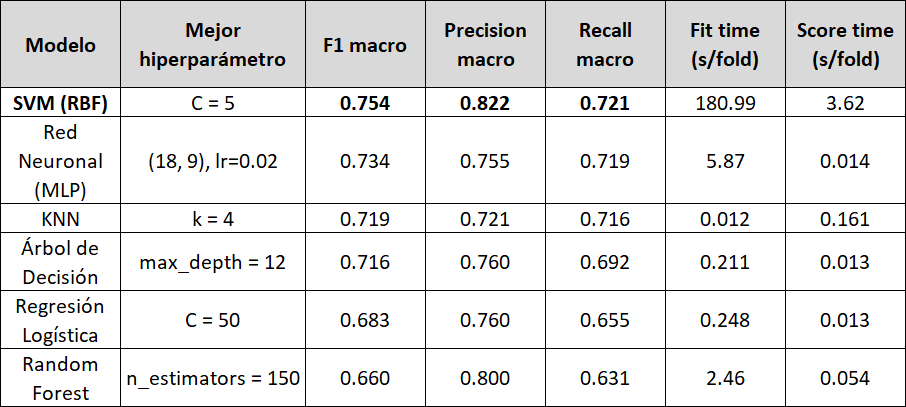

Tabla comparativa - mejor hiperparametro por modelo con metricas clase 0

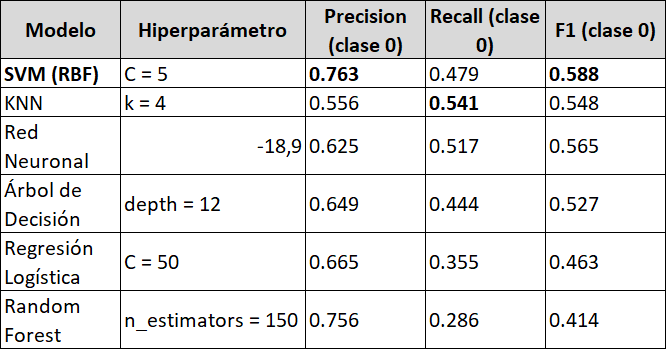

Si bien la SVM es el modelo con mejores resultados tanto a nivel macro como para la clase 0 tomando el recall como la medida mas critica por la naturaleza del obketivo predictivo, se escoge la Red neuronal por ser la que mejor balance entre recall, precision y f1 score presenta para la clase 0, adicional de ser la segunda mejor en resultados macro. Ademas los tiempos de ejecucion son pertinentes para un despliegue frente a un costo computacional elevado como el de SVM

#Modelo elegido red neuronal

In [110]:
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation="logistic",hidden_layer_sizes=(18,9), learning_rate='constant',
                     learning_rate_init=0.02, momentum= 0.03, max_iter=500, random_state=3)


scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

scores


,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro
0,30.577002,0.022355,0.733586,0.804897,0.835456,0.879210,0.742750,0.816101,0.725809,0.795175
1,20.027315,0.057781,0.738613,0.786712,0.845276,0.875494,0.762306,0.821713,0.721982,0.763105
2,23.189120,0.019458,0.746913,0.798708,0.848992,0.880419,0.768329,0.826639,0.731278,0.778347
3,22.568072,0.020543,0.738281,0.789812,0.847399,0.876968,0.768347,0.823783,0.718645,0.766595
4,23.855328,0.019607,0.724695,0.800129,0.835456,0.880566,0.744048,0.825479,0.710683,0.781177
5,30.935930,0.018821,0.734694,0.811398,0.829883,0.878119,0.734346,0.808436,0.735044,0.814489
6,28.006671,0.019139,0.732995,0.791335,0.839968,0.875288,0.752036,0.815891,0.718972,0.773011
7,28.243161,0.019625,0.733294,0.802027,0.839968,0.879917,0.751968,0.821083,0.719470,0.786855
8,24.910481,0.019456,0.723753,0.787299,0.840988,0.876618,0.757010,0.825492,0.703376,0.762202
9,20.394325,0.020588,0.730484,0.792215,0.845235,0.878417,0.765710,0.826666,0.709019,0.768690


In [111]:
scores.mean()

,0
fit_time,25.270740
score_time,0.023737
test_f1_macro,0.733731
train_f1_macro,0.796453
test_accuracy,0.840862
train_accuracy,0.878102
test_precision_macro,0.754685
train_precision_macro,0.821128
test_recall_macro,0.719428
train_recall_macro,0.778964


In [112]:
model_rn.fit(X,Y)

MLPClassifier(activation='logistic', hidden_layer_sizes=(18, 9),
              learning_rate_init=0.02, max_iter=500, momentum=0.03,
              random_state=3)

In [59]:
import pickle
filename = 'modelo-rn.pkl'
variables=X.columns._values
pickle.dump([model_knn,labelencoder,variables,min_max_scaler], open(filename, 'wb'))